https://cicresearch.ca//CICDataset/CIC-UNSW/browse.php?t=1775399957621

| Label | Class | 
|---|---|
| 0 | Benign |
| 1 | Analysis |
| 2 | Backdoor |
| 3 | DoS |
| 4 | Exploits |
| 5 | Fuzzers |
| 6 | Generic |
| 7 | Reconnaissance |
| 8 | Shellcode |
| 9 | Worms |

| Column | Description |
|---|---|
| Flow Duration | Total duration of the network flow in microseconds |
| Total Fwd Packet | Number of packets sent in the forward direction (client → server) |
| Total Bwd Packets | Number of packets sent in the backward direction (server → client) |
| Total Length of Fwd Packet | Total size in bytes of all forward packets |
| Total Length of Bwd Packet | Total size in bytes of all backward packets |
| Fwd Packet Length Max | Largest forward packet size in bytes |
| Fwd Packet Length Min | Smallest forward packet size in bytes |
| Fwd Packet Length Mean | Average forward packet size in bytes |
| Fwd Packet Length Std | Standard deviation of forward packet sizes |
| Bwd Packet Length Max | Largest backward packet size in bytes |
| Bwd Packet Length Min | Smallest backward packet size in bytes |
| Bwd Packet Length Mean | Average backward packet size in bytes |
| Bwd Packet Length Std | Standard deviation of backward packet sizes |
| Flow Bytes/s | Total bytes transferred per second in the flow |
| Flow Packets/s | Total packets transmitted per second in the flow |
| Flow IAT Mean | Average time between any two packets in the flow (Inter-Arrival Time) |
| Flow IAT Std | Standard deviation of inter-arrival times across the whole flow |
| Flow IAT Max | Longest gap between any two consecutive packets in the flow |
| Flow IAT Min | Shortest gap between any two consecutive packets in the flow |
| Fwd IAT Total | Total time between forward packets across the entire flow |
| Fwd IAT Mean | Average time between consecutive forward packets |
| Fwd IAT Std | Standard deviation of forward inter-arrival times |
| Fwd IAT Max | Longest gap between two consecutive forward packets |
| Fwd IAT Min | Shortest gap between two consecutive forward packets |
| Bwd IAT Total | Total time between backward packets across the entire flow |
| Bwd IAT Mean | Average time between consecutive backward packets |
| Bwd IAT Std | Standard deviation of backward inter-arrival times |
| Bwd IAT Max | Longest gap between two consecutive backward packets |
| Bwd IAT Min | Shortest gap between two consecutive backward packets |
| Fwd PSH Flags | Number of PSH flag packets in the forward direction (forces data flush) |
| Bwd PSH Flags | Number of PSH flag packets in the backward direction |
| Fwd URG Flags | Number of URG flag packets in the forward direction (urgent data) |
| Bwd URG Flags | Number of URG flag packets in the backward direction |
| Fwd Header Length | Total bytes used by headers in forward packets |
| Bwd Header Length | Total bytes used by headers in backward packets |
| Fwd Packets/s | Number of forward packets transmitted per second |
| Bwd Packets/s | Number of backward packets transmitted per second |
| Packet Length Min | Smallest packet size across the entire flow |
| Packet Length Max | Largest packet size across the entire flow |
| Packet Length Mean | Average packet size across the entire flow |
| Packet Length Std | Standard deviation of packet sizes across the entire flow |
| Packet Length Variance | Variance of packet sizes — higher variance can indicate unusual traffic |
| FIN Flag Count | Number of FIN flags — indicates connection termination attempts |
| SYN Flag Count | Number of SYN flags — indicates connection initiation attempts |
| RST Flag Count | Number of RST flags — indicates abrupt connection resets |
| PSH Flag Count | Number of PSH flags across the full flow |
| ACK Flag Count | Number of ACK flags — acknowledgement of received data |
| URG Flag Count | Number of URG flags across the full flow |
| CWR Flag Count | Number of CWR flags — congestion window reduced signal |
| ECE Flag Count | Number of ECE flags — explicit congestion notification echo |
| Down/Up Ratio | Ratio of download (backward) to upload (forward) traffic volume |
| Average Packet Size | Mean size of all packets in the flow |
| Fwd Segment Size Avg | Average segment size in the forward direction |
| Bwd Segment Size Avg | Average segment size in the backward direction |
| Fwd Bytes/Bulk Avg | Average bytes per bulk transfer in the forward direction |
| Fwd Packet/Bulk Avg | Average packets per bulk transfer in the forward direction |
| Fwd Bulk Rate Avg | Average bulk transfer rate in the forward direction |
| Bwd Bytes/Bulk Avg | Average bytes per bulk transfer in the backward direction |
| Bwd Packet/Bulk Avg | Average packets per bulk transfer in the backward direction |
| Bwd Bulk Rate Avg | Average bulk transfer rate in the backward direction |
| Subflow Fwd Packets | Average number of forward packets in a subflow |
| Subflow Fwd Bytes | Average number of forward bytes in a subflow |
| Subflow Bwd Packets | Average number of backward packets in a subflow |
| Subflow Bwd Bytes | Average number of backward bytes in a subflow |
| FWD Init Win Bytes | Number of bytes in the initial forward TCP window — reveals buffer size |
| Bwd Init Win Bytes | Number of bytes in the initial backward TCP window |
| Fwd Act Data Pkts | Number of forward packets that carried actual payload data |
| Fwd Seg Size Min | Minimum segment size observed in the forward direction |
| Active Mean | Average time the flow was active before going idle |
| Active Std | Standard deviation of active time periods |
| Active Max | Longest active period in the flow |
| Active Min | Shortest active period in the flow |
| Idle Mean | Average time the flow was idle between active periods |
| Idle Std | Standard deviation of idle time periods |
| Idle Max | Longest idle period in the flow |
| Idle Min | Shortest idle period in the flow |
| Label | Attack category — 0=Benign, 1=Analysis, 2=Backdoor, 3=DoS, 4=Exploits, 5=Fuzzers, 6=Generic, 7=Reconnaissance, 8=Shellcode, 9=Worms |

## Setup
Import core libraries for data manipulation, visualization, and machine learning.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import scipy as sc

### Load Feature Data
Read the raw network flow features from `Data.csv` (UNSW-NB15 2024 dataset).

In [7]:
data_file = "~/Desktop/Coding projects for fun/Github improvement/IDS project/Data.csv"
# Load raw network flow features from CSV
data = pd.read_csv(data_file) 

# Confirm dimensions (rows, columns)
print(data.shape)


(447915, 76)


Inspect column names in the raw feature file.

In [9]:
data.columns

Index(['Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag C

Preview the first few rows of the raw feature data.

In [11]:
data.head()

,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,214392,9,21,388.0,24564.0,194.0,0.0,43.111111,85.545959,1460.0,...,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2376792,9,3,752.0,0.0,188.0,0.0,83.555556,99.084700,0.0,...,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,131350,10,3,7564.0,0.0,1460.0,0.0,756.400000,690.497277,0.0,...,6,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,164796,6,3,770.0,0.0,385.0,0.0,128.333333,198.813145,0.0,...,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,163418,6,3,400.0,0.0,200.0,0.0,66.666667,103.279556,0.0,...,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Load Labels
Read traffic class labels from `label.csv`.

In [13]:
label_file = "~/Desktop/Coding projects for fun/Github improvement/IDS project/label.csv"
# Load class labels from separate CSV
label_df = pd.read_csv(label_file)
print(label_df.shape) 


(447915, 1)


Inspect column names in the label file.

In [15]:
label_df.loc[label_df["Label"]==8]

,Label
206,8
228,8
250,8
323,8
343,8
...,...
444785,8
445128,8
445274,8
445458,8


Preview the first few rows of the label file.

In [17]:
# Clean labels at source before merging

#merging the rare attack types
def merge_rare(label):
    if label == 1 or label == 2 or label == 9:
        return 10
    return label

label_df['Label'] = label_df['Label'].apply(merge_rare)

# Remap to 0–7
LABEL_REMAP = {0:0, 4:1, 5:2, 7:3, 6:4, 3:5, 8:6, 10:7}
label_df['Label'] = label_df['Label'].map(LABEL_REMAP)

print("\nRemapped label counts:")
print(label_df['Label'].value_counts().sort_index())

# Drop Label from data if it already exists to avoid duplication
if 'Label' in data.columns:
    data = data.drop(columns=['Label'])

# Now merge
df = pd.concat([data, label_df], axis=1)

print("\nFinal df label counts:")
print(df['Label'].value_counts().sort_index())
print("Final df shape:", df.shape)


Remapped label counts:
Label
0    358332
1     30951
2     29613
3     16735
4      4632
5      4467
6      2102
7      1083
Name: count, dtype: int64

Final df label counts:
Label
0    358332
1     30951
2     29613
3     16735
4      4632
5      4467
6      2102
7      1083
Name: count, dtype: int64
Final df shape: (447915, 77)


In [18]:
df.dtypes

Flow Duration                   int64
Total Fwd Packet                int64
Total Bwd packets               int64
Total Length of Fwd Packet    float64
Total Length of Bwd Packet    float64
                               ...   
Idle Mean                     float64
Idle Std                      float64
Idle Max                      float64
Idle Min                      float64
Label                           int64
Length: 77, dtype: object

List all columns in the combined DataFrame.

In [20]:
#drop duplicate values
df.drop_duplicates(inplace=True) 
print(df['Label'].value_counts())

Label
0    225003
1     30910
2     26395
3     12031
4      4496
5      4412
6      1848
7      1078
Name: count, dtype: int64


Check for missing (NaN) values across all columns.

In [22]:
#how many null values are in the dataset
df.isna().sum()

Flow Duration                 0
Total Fwd Packet              0
Total Bwd packets             0
Total Length of Fwd Packet    0
Total Length of Bwd Packet    0
                             ..
Idle Mean                     0
Idle Std                      0
Idle Max                      0
Idle Min                      0
Label                         0
Length: 77, dtype: int64

Preview the first few rows of the combined feature + label DataFrame.

In [24]:
print("First 5 rows of the combined_dataset:")
df.head()

First 5 rows of the combined_dataset:


,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,214392,9,21,388.0,24564.0,194.0,0.0,43.111111,85.545959,1460.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2376792,9,3,752.0,0.0,188.0,0.0,83.555556,99.084700,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,131350,10,3,7564.0,0.0,1460.0,0.0,756.400000,690.497277,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,164796,6,3,770.0,0.0,385.0,0.0,128.333333,198.813145,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
4,163418,6,3,400.0,0.0,200.0,0.0,66.666667,103.279556,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


DataFrame schema: dtypes, non-null counts, and memory usage.

In [26]:
print("\nInfo about the combined_dataset:")
df.info()


Info about the combined_dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 306173 entries, 0 to 447911
Data columns (total 77 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow Duration               306173 non-null  int64  
 1   Total Fwd Packet            306173 non-null  int64  
 2   Total Bwd packets           306173 non-null  int64  
 3   Total Length of Fwd Packet  306173 non-null  float64
 4   Total Length of Bwd Packet  306173 non-null  float64
 5   Fwd Packet Length Max       306173 non-null  float64
 6   Fwd Packet Length Min       306173 non-null  float64
 7   Fwd Packet Length Mean      306173 non-null  float64
 8   Fwd Packet Length Std       306173 non-null  float64
 9   Bwd Packet Length Max       306173 non-null  float64
 10  Bwd Packet Length Min       306173 non-null  float64
 11  Bwd Packet Length Mean      306173 non-null  float64
 12  Bwd Packet Length Std       306173 non-null

Descriptive statistics (mean, std, min, max, quartiles) for every numeric feature.

In [28]:
print("\nDescriptive statistics for the combined_dataset:")
print(df.describe())


Descriptive statistics for the combined_dataset:
       Flow Duration  Total Fwd Packet  Total Bwd packets  \
count   3.061730e+05     306173.000000      306173.000000   
mean    8.740835e+05         32.433167          38.881397   
std     5.879723e+06        153.768982         139.400931   
min     1.000000e+00          1.000000           0.000000   
25%     4.777000e+03          3.000000           2.000000   
50%     5.292200e+04          9.000000           7.000000   
75%     5.346830e+05         38.000000          37.000000   
max     1.199975e+08      20038.000000       11021.000000   

       Total Length of Fwd Packet  Total Length of Bwd Packet  \
count                3.061730e+05                3.061730e+05   
mean                 6.973511e+03                3.165550e+04   
std                  1.836319e+05                1.776357e+05   
min                  0.000000e+00                0.000000e+00   
25%                  7.400000e+01                0.000000e+00   
50%       

Count missing values per column in the combined DataFrame.

In [30]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Flow Duration                 0
Total Fwd Packet              0
Total Bwd packets             0
Total Length of Fwd Packet    0
Total Length of Bwd Packet    0
                             ..
Idle Mean                     0
Idle Std                      0
Idle Max                      0
Idle Min                      0
Label                         0
Length: 77, dtype: int64


### Class Distribution
Bar chart of sample counts per class — reveals the degree of class imbalance the models must handle.

/var/folders/9s/jwyj784906ndy4td5h3gqtnw0000gn/T/ipykernel_1433/3641530655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_col, palette='viridis') #gives us a barplot


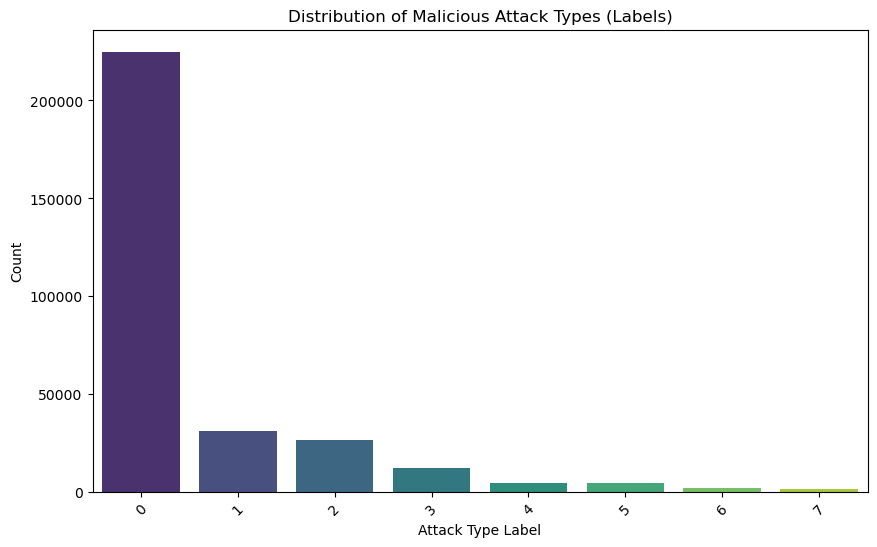

In [32]:
def plot_class_distribution(df, label_col='Label', title='Distribution of Malicious Attack Types (Labels)'):
    plt.figure(figsize=(10, 6)) #figure size
    sns.countplot(data=df, x=label_col, palette='viridis') #gives us a barplot
    plt.title(title) #gives us the title of the plot which is put in the function
    plt.xlabel('Attack Type Label')# gives us the lael of the x axis
    plt.ylabel('Count')# gives us the lael of the y axis
    plt.xticks(rotation=45)#rotates the vlaues of the x-axis 45 degrees
    plt.show()#shows the plot

plot_class_distribution(df)#call the function

### Correlation Heatmap
Full pairwise Pearson correlation matrix across all features — helps spot redundant columns before feature selection.

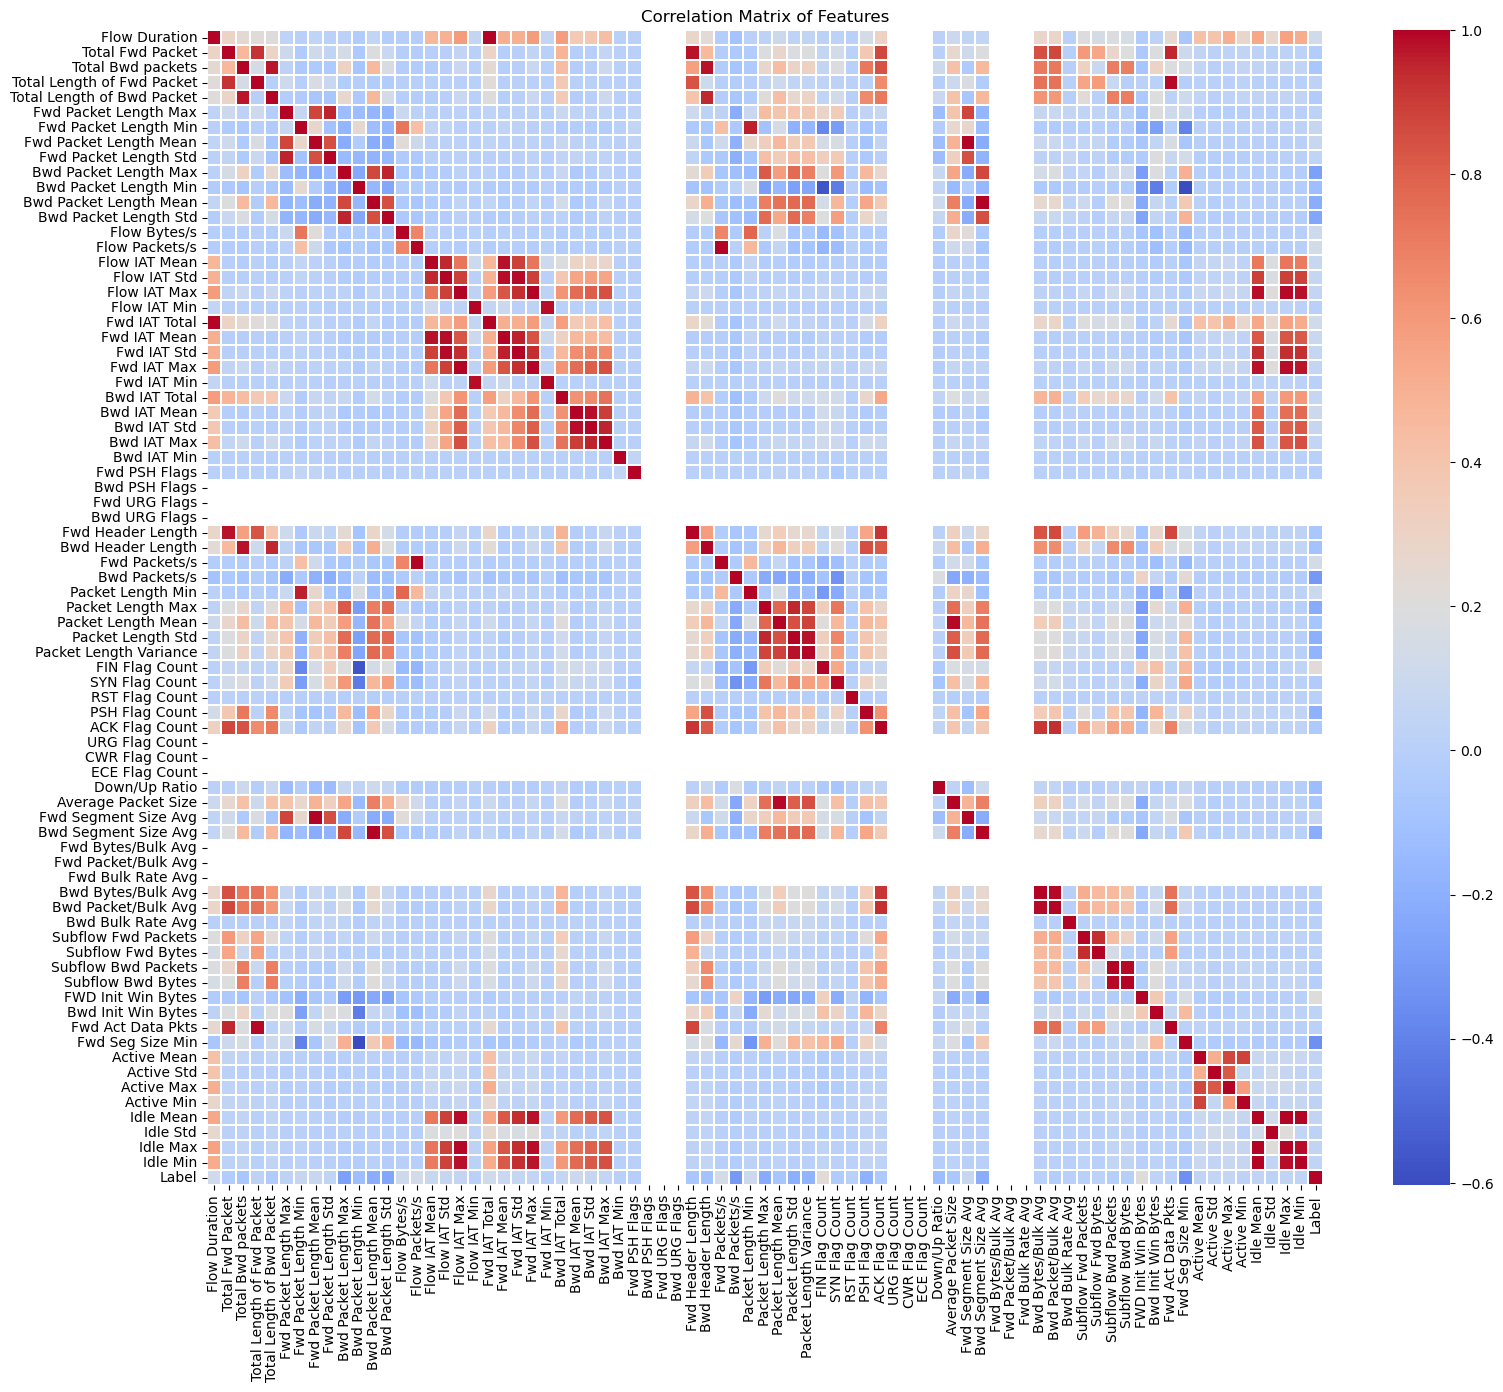

In [34]:
def plot_correlation_heatmap(df, title='Correlation Matrix of Features'):
    plt.figure(figsize=(18, 15))
    corr = df.corr()#gets us the correlation of each feature
    sns.heatmap(corr, cmap='coolwarm', fmt=".2f", linewidths=.05)#creates a blue to red heat map of corr
    plt.title(title)#title is called in the function
    plt.show()#shows the heatmap

plot_correlation_heatmap(df)#calls the function the visualization is in

### Global Plot Style + Label Map
Set a dark-theme matplotlib style and define the integer → class-name mapping used throughout the notebook.

In [36]:
#background colors for visualizations
plt.rcParams.update({
    'figure.facecolor': '#0f1117',  # outer figure bg — near-black, 1 shade darker than axes
    'axes.facecolor':   '#1a1d2e',  # plot area bg — deep navy, the "canvas"
    'axes.edgecolor':   '#2e3250',  # border around the axes box
    'axes.labelcolor':  '#c8cde8',  # x/y axis labels — cool lavender white
    'xtick.color':      '#7b82b0',  # x-axis tick labels — muted slate blue
    'ytick.color':      '#7b82b0',  # y-axis tick labels — same as xtick
    'text.color':       '#c8cde8',  # all other text (titles, annotations) — same as labels
    'grid.color':       '#2e3250',  # gridlines — same as axes edge, very subtle
    'grid.linewidth':   0.6,        # thin gridlines so they don't compete with data
    'font.family':      'monospace',
})
 
# Map integer class IDs to human-readable attack names
LABEL_MAP = {
    0: 'Benign',
    1: 'Exploits',
    2: 'Fuzzers',
    3: 'Recon',
    4: 'Generic',
    5: 'DoS',
    6: 'Shellcode',
    7: 'Rare_Attack',  # Analysis + Backdoor + Worms
}
 
# Assign a distinct color to each of the 10 attack classes
PALETTE = [
    '#4fc3f7',  # sky blue      — cool, high contrast; good for primary series
    '#ff6b6b',  # coral red     — warm accent; alerts, anomalies, fraud flags
    '#69db7c',  # mint green    — positive/normal state; benign traffic
    '#ffd43b',  # amber         — warning; mid-risk signals
    '#da77f2',  # orchid        — secondary categorical; model B or feature group
    '#ff922b',  # tangerine     — medium urgency; complements amber without clashing
    '#74c0fc',  # cornflower    — lighter sibling of sky blue; paired series
    '#f06595',  # rose          — distinct from coral; 8th category
]


Map numeric `Label` integers to human-readable class names in a new `Label_Name` column.

In [38]:
# Map numeric labels to names if Label column is numeric. np.float64 may not be needed here.
if df['Label'].dtype in [np.int64, np.float64]:
    # Translate numeric label to class name string
    df['Label_Name'] = df['Label'].map(LABEL_MAP)
else:
    df['Label_Name'] = df['Label']


## Exploratory Data Analysis
### Data Quality Audit
Scan for infinite values, missing values, and zero-variance columns.

In [40]:
# 1. INFINITE / MISSING VALUE CHECK
print("=" * 60)
print("1. DATA QUALITY CHECK")
print("=" * 60)
 
# Isolate numeric columns — inf/NaN checks only apply to these 
    #looks for any columns with  numeric datatype
numeric_cols = df.select_dtypes(include=[np.number]).columns
 
# Infinite values per column
inf_counts = {}
for col in numeric_cols:
    # Count infinite values in this column. Loops through each column and stores in inf_counts. 
    n = np.isinf(df[col]).sum()
    if n > 0:
        inf_counts[col] = n
 
print(f"\n🔴 Columns with Inf values ({len(inf_counts)} found):") 
#if there are inf_counts we sort the items in the dictionary
if inf_counts:
    for col, n in sorted(inf_counts.items(), key=lambda x: -x[1]):
        print(f"{col:<40} {n:>8,} inf values")
else:
    print("None found ✅")
 
# Missing values
# Count NaN values per column
missing = df.isnull().sum() 
missing = missing[missing > 0]
print(f"\n🟡 Columns with NaN values ({len(missing)} found):") 
#looking for how many missing there are 
if len(missing):
    for col, n in missing.items():
        print(f"{col:<40} {n:>8,} missing")
else:
    print("None found ✅")
 
# Zero-variance columns
# Flag columns with only one unique value — zero discriminative power 
zero_var = [c for c in numeric_cols if df[c].nunique() <= 1] #List comprehension to find zero variance cols
print(f"\n⚪ Zero-variance columns ({len(zero_var)} found):")
if zero_var:
    for c in zero_var:
        print(f"   {c}")
else:
    print("None found ✅") 

missing

1. DATA QUALITY CHECK

🔴 Columns with Inf values (0 found):
None found ✅

🟡 Columns with NaN values (0 found):
None found ✅

⚪ Zero-variance columns (9 found):
   Bwd PSH Flags
   Fwd URG Flags
   Bwd URG Flags
   URG Flag Count
   CWR Flag Count
   ECE Flag Count
   Fwd Bytes/Bulk Avg
   Fwd Packet/Bulk Avg
   Fwd Bulk Rate Avg


Series([], dtype: int64)

### EDA 1 — Flow Packets/s vs Flow Bytes/s
Scatter plot colored by attack class to reveal traffic-rate signatures.

1. FLOW PACKETS/s vs FLOW BYTES/s SCATTER


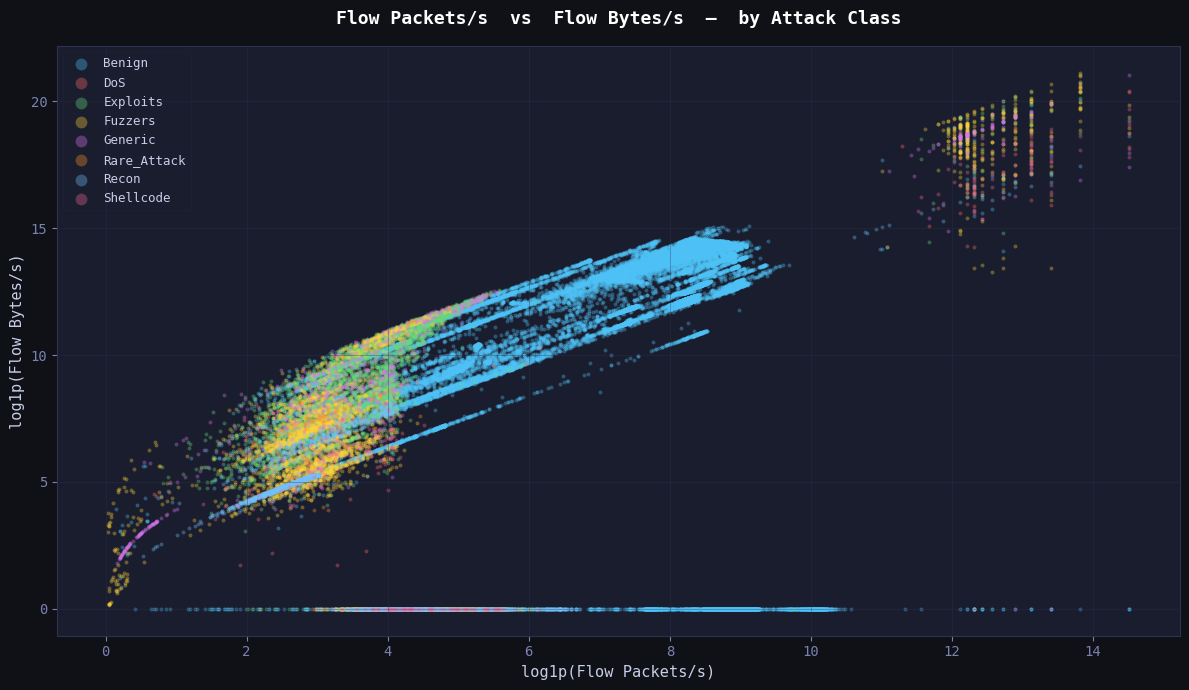

✅ Saved: scatter_packets_vs_bytes.png


In [42]:
# 2. FLOW PACKETS/s vs FLOW BYTES/s SCATTER (colored by label)
#setting the size and color of the figure 
print("=" * 60)
print("1. FLOW PACKETS/s vs FLOW BYTES/s SCATTER")
print("=" * 60) 
#setting the size and color of the figure
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f1117')
 
# Replace inf before plotting
# Drop rows with inf/NaN in the plotted columns before rendering 
    #replaces infinite with nan and drops any nans in the subset 
plot_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Flow Packets/s', 'Flow Bytes/s', 'Label_Name'])
 
# Sample for readability if dataset is large
# Cap at 50k points so the scatter plot stays readable
sample = plot_df.sample(min(50_000, len(plot_df)), random_state=42)
#loop through the label names to chart each attack class
for i, (label_name, group) in enumerate(sample.groupby('Label_Name')):
    ax.scatter(
        np.log1p(group['Flow Packets/s']),  # x-axis: log(1 + Flow Packets/s) to compress skewed data
        np.log1p(group['Flow Bytes/s']),    # y-axis: log(1 + Flow Bytes/s) to compress skewed data
        label=label_name,                   # legend entry for this traffic class
        alpha=0.35,                         # 35% opacity so overlapping points are visible
        s=8,                                # small marker size since you likely have many points
        color=PALETTE[i % len(PALETTE)],    # assign a unique color per label, cycling if needed
        linewidths=0                        # remove marker border/outline for cleaner look
    )
 
ax.set_xlabel('log1p(Flow Packets/s)', fontsize=11)        # x-axis label, font size 11
ax.set_ylabel('log1p(Flow Bytes/s)', fontsize=11)          # y-axis label, font size 11
ax.set_title('Flow Packets/s  vs  Flow Bytes/s  —  by Attack Class',
             fontsize=13,          # title font size
             pad=16,               # spacing between title and plot
             color='white',        # white title text (dark background theme)
             fontweight='bold')    # bold title
ax.legend(markerscale=3,           # enlarges legend markers so small s=8 dots are visible
          framealpha=0.15,         # semi-transparent legend background
          fontsize=9,              # legend text size
          facecolor='#1a1d2e',     # legend background color (matches dark theme)
          edgecolor='#2e3250')     # legend border color
ax.grid(True, alpha=0.4)           # show grid lines at 40% opacity
plt.tight_layout()                 # auto-adjust spacing so nothing gets clipped
plt.savefig('scatter_packets_vs_bytes.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')#save the figure so we can put it on github later
plt.show()
print("✅ Saved: scatter_packets_vs_bytes.png")


### EDA 2 — Flow Duration by Class
Log-scaled box plots show how long each attack type sustains a network connection.

/var/folders/9s/jwyj784906ndy4td5h3gqtnw0000gn/T/ipykernel_1433/4170989795.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


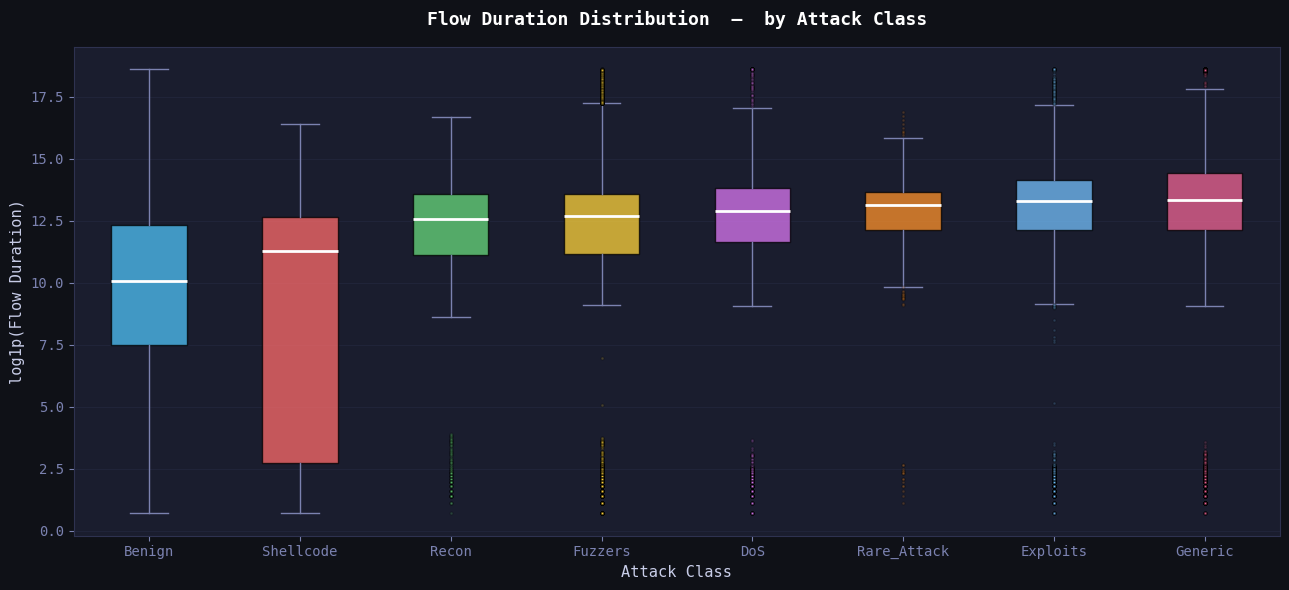

✅ Saved: boxplot_flow_duration.png


In [44]:
# 3. BOX PLOTS — Flow Duration by Attack Class
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
#replace infinites with nan and then we drop any rows with missing flow duration or label name
plot_df2 = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Flow Duration', 'Label_Name'])
# log-scale duration so extreme outliers do not crush the y-axis
plot_df2['log_duration'] = np.log1p(plot_df2['Flow Duration'])

# sort attack classes by median log_duration so boxes appear in ascending order
order = plot_df2.groupby('Label_Name')['log_duration'].median().sort_values().index.tolist()

# creates the boxplots
bp = ax.boxplot(
    [plot_df2[plot_df2['Label_Name'] == lbl]['log_duration'].values for lbl in order],  # builds a list of arrays, one per attack class, in the specified order
    labels=order,                                         # sets the x-axis tick label for each box to the attack class name
    patch_artist=True,                                    # fills the boxes with color (required to apply facecolor later)
    medianprops=dict(color='white', linewidth=2),         # median line inside each box: white and slightly thick
    whiskerprops=dict(color='#7b82b0'),                   # whisker lines (extending to min/max within 1.5*IQR): muted purple
    capprops=dict(color='#7b82b0'),                       # cap lines at the ends of whiskers: same muted purple
    flierprops=dict(marker='o', markersize=2, alpha=0.2, linestyle='none')  # outlier points: small faint circles so they don't dominate
)

# apply palette colors to each box
for patch, color in zip(bp['boxes'], PALETTE):  # pairs each box with a color from the palette
    patch.set_facecolor(color)                  # fills the box with its assigned color
    patch.set_alpha(0.75)                       # makes the box slightly transparent

# match outlier dot colors to their respective box
for flier, color in zip(bp['fliers'], PALETTE): # pairs each set of outlier points with a color from the palette
    flier.set_markerfacecolor(color)            # colors the outlier dots to match their box

ax.set_xlabel('Attack Class', fontsize=11)#x axis label
ax.set_ylabel('log1p(Flow Duration)', fontsize=11)#y axis label
ax.set_title('Flow Duration Distribution  —  by Attack Class',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('boxplot_flow_duration.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: boxplot_flow_duration.png")
 
 


### EDA 3 — TCP Flag Rates by Class
Stacked bar of mean TCP flag counts per class — SYN/ACK ratios expose scan and DoS patterns.

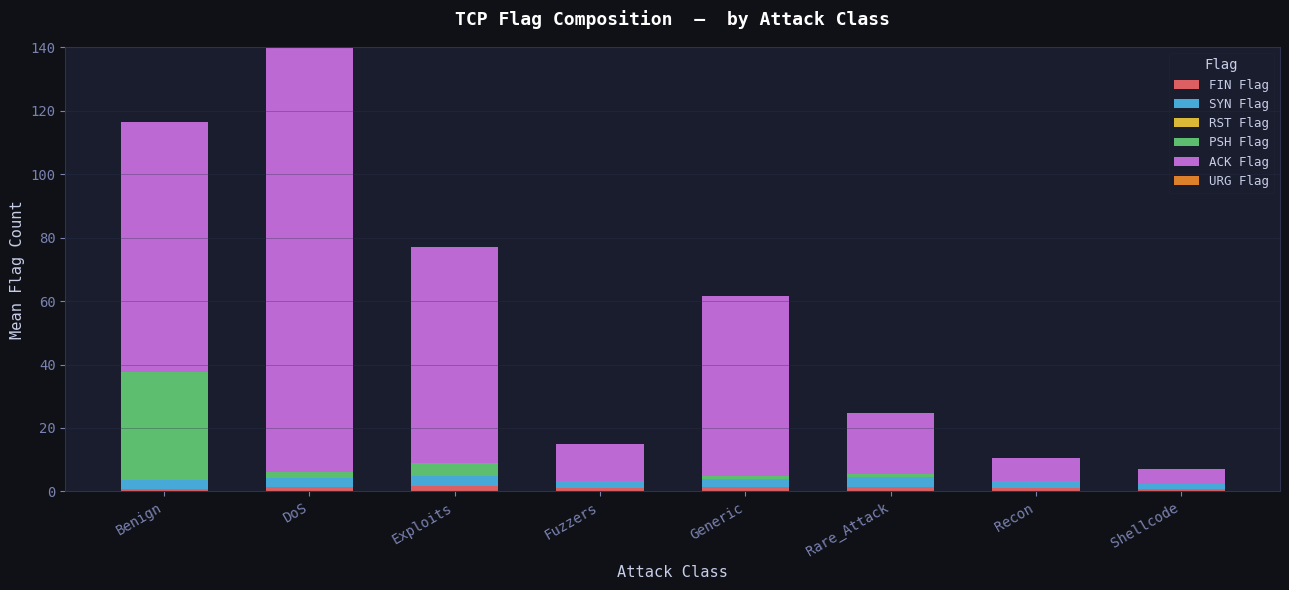

✅ Saved: flags_stacked_bar.png


In [46]:
# 4. TCP FLAG STACKED BAR — by Attack Class

flag_cols = ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count',
             'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count']
# Guard against flag columns dropped in feature selection
flag_cols = [c for c in flag_cols if c in df.columns]
 
# Average flag counts per class to reveal TCP signature patterns
flag_df = df.groupby('Label_Name')[flag_cols].mean()
 
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
 
flag_colors = ['#ff6b6b', '#4fc3f7', '#ffd43b', '#69db7c', '#da77f2', '#ff922b']


bottom = np.zeros(len(flag_df))  # initialize a zero baseline for each bar (one per row in flag_df)
for i, col in enumerate(flag_cols):
    ax.bar(
        flag_df.index,                        # x-axis positions (the attack class labels)
        flag_df[col],                         # height of this segment for each bar
        bottom=bottom,                        # start this segment where the previous one ended (stacking)
        label=col.replace(' Count', ''),      # strip ' Count' from column name for a cleaner legend entry
        color=flag_colors[i % len(flag_colors)],  # assign a unique color per flag type, cycling if needed
        alpha=0.85,                           # slight transparency
        width=0.6                             # bar width
    )
    bottom += flag_df[col].values             # shift the baseline up by this segment's values so the next flag stacks on top
 
ax.set_xlabel('Attack Class', fontsize=11)
ax.set_ylabel('Mean Flag Count', fontsize=11)
ax.set_title('TCP Flag Composition  —  by Attack Class',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.legend(title='Flag', framealpha=0.15, facecolor='#1a1d2e',
          edgecolor='#2e3250', fontsize=9) #create the legend in the top right of the chart
ax.grid(True, axis='y', alpha=0.4)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('flags_stacked_bar.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: flags_stacked_bar.png")
 


### EDA 4 — Inter-Arrival Time by Class
Violin plots of log-scaled IAT Mean reveal burstiness and timing differences across attack types.

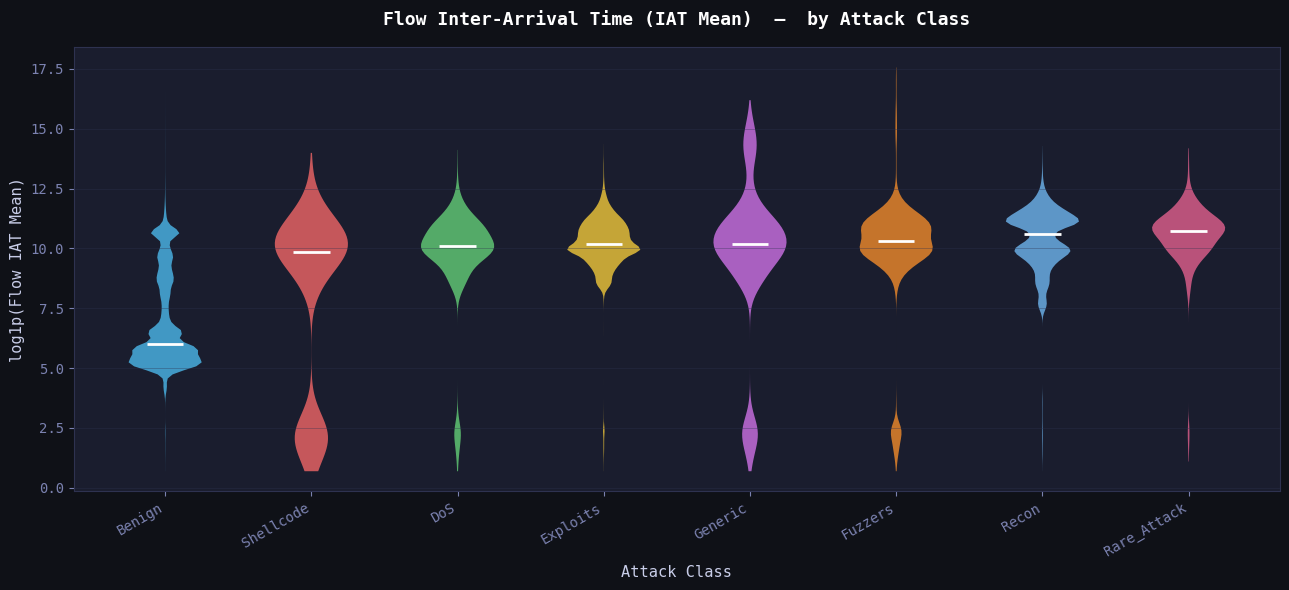

✅ Saved: violin_iat_mean.png


In [48]:
# 5. VIOLIN PLOTS — Flow IAT Mean by Attack Class

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
 
plot_df3 = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['Flow IAT Mean', 'Label_Name']).copy()
# Clip negatives then log-scale to handle extreme IAT values
plot_df3['log_iat'] = np.log1p(plot_df3['Flow IAT Mean'].clip(lower=0))#bounds the minimum value of Flow IAT Mean to zero
 
# Clip negatives then log-scale to handle extreme IAT values
order3 = plot_df3.groupby('Label_Name')['log_iat'].median().sort_values().index.tolist()
 
parts = ax.violinplot(
    # Clip negatives then log-scale to handle extreme IAT values
    [plot_df3[plot_df3['Label_Name'] == lbl]['log_iat'].values for lbl in order3],
    positions=range(len(order3)),
    showmedians=True,
    showextrema=False
)
 
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i % len(PALETTE)])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)
 
ax.set_xticks(range(len(order3)))
ax.set_xticklabels(order3, rotation=30, ha='right')
ax.set_xlabel('Attack Class', fontsize=11)
ax.set_ylabel('log1p(Flow IAT Mean)', fontsize=11)
ax.set_title('Flow Inter-Arrival Time (IAT Mean)  —  by Attack Class',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('violin_iat_mean.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: violin_iat_mean.png")
 


### EDA 5 — Mutual Information Scores
Rank features by mutual information with the label to identify the strongest predictors.


6. MUTUAL INFORMATION SCORES (top 20 features)


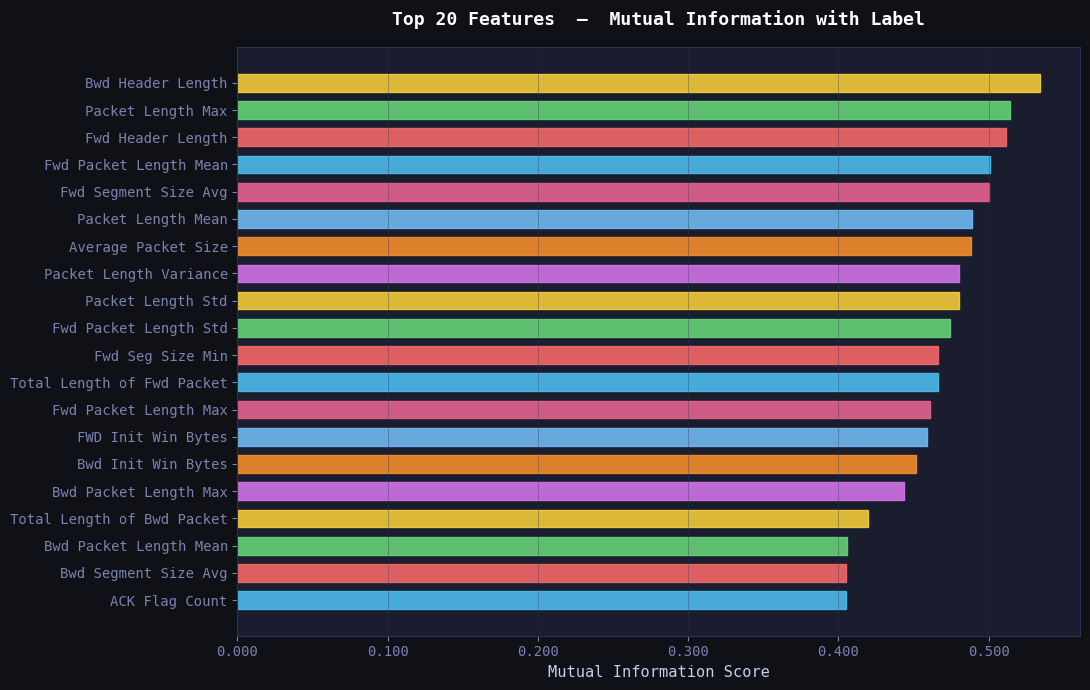

✅ Saved: mutual_information.png

📊 Top 20 features by mutual information:
   Bwd Header Length                             0.5341
   Packet Length Max                             0.5142
   Fwd Header Length                             0.5113
   Fwd Packet Length Mean                        0.5010
   Fwd Segment Size Avg                          0.5001
   Packet Length Mean                            0.4887
   Average Packet Size                           0.4884
   Packet Length Variance                        0.4805
   Packet Length Std                             0.4805
   Fwd Packet Length Std                         0.4744
   Fwd Seg Size Min                              0.4664
   Total Length of Fwd Packet                    0.4661
   Fwd Packet Length Max                         0.4612
   FWD Init Win Bytes                            0.4591
   Bwd Init Win Bytes                            0.4514
   Bwd Packet Length Max                         0.4436
   Total Length of Bwd Packet 

In [50]:
import matplotlib.ticker as ticker
print("\n" + "=" * 60)
print("6. MUTUAL INFORMATION SCORES (top 20 features)")
print("=" * 60) 
#we are looking to find the 20 best features
from sklearn.feature_selection import mutual_info_classif
mi_df = df.replace([np.inf, -np.inf], np.nan).dropna()
feature_cols = [c for c in numeric_cols if c != 'Label'] #all non-tgt variable columns
X_mi = mi_df[feature_cols].fillna(0)
y_mi = mi_df['Label']
 
# Score each feature by how much information it shares with the label
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
# Rank all features from most to least informative
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
# Keep the 20 highest-MI features for visualisation
top20 = mi_series.head(20)
 
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f1117')
 #horizontal bar graph
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=PALETTE[0], alpha=0.85, height=0.65)
 
# Color gradient from low to high
for i, bar in enumerate(bars):
    bar.set_color(PALETTE[i % len(PALETTE)])
 
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('Top 20 Features  —  Mutual Information with Label',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.grid(True, axis='x', alpha=0.4)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: mutual_information.png")
 
print("\n📊 Top 20 features by mutual information:")
for feat, score in top20.items():
    print(f"   {feat:<45} {score:.4f}")
 


### EDA 6 — Mean Feature Values per Class
Normalized heatmap of the top-15 MI features per class — reveals class-specific feature signatures.

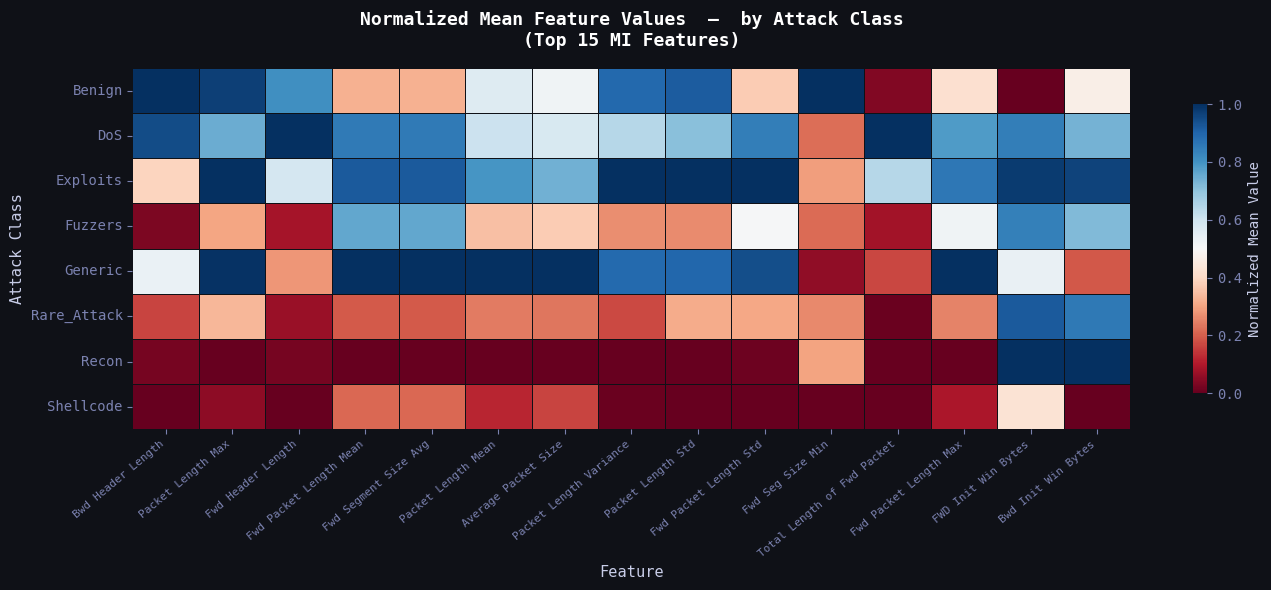

✅ Saved: heatmap_class_means.png

✅ All EDA plots complete!


In [52]:
# 7. Mean feature values per class (heatmap)
# Pick most informative features from MI scores
# Select top 15 MI features for the class-mean heatmap
top_features = top20.head(15).index.tolist()
 
# Compute mean value of each top feature grouped by attack class
class_means = df.replace([np.inf, -np.inf], np.nan).groupby('Label_Name')[top_features].mean()
 
# Normalize each feature to 0-1 for readability
# Min-max normalise so features on different scales are comparable
class_means_norm = (class_means - class_means.min()) / (class_means.max() - class_means.min() + 1e-9)
 
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
 
sns.heatmap(
    # Min-max normalise so features on different scales are comparable
    class_means_norm,
    ax=ax,
    cmap='RdBu',
    linewidths=0.4,
    linecolor='#0f1117',
    annot=False,
    cbar_kws={'shrink': 0.8, 'label': 'Normalized Mean Value'}
)
 
ax.set_title('Normalized Mean Feature Values  —  by Attack Class\n(Top 15 MI Features)',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Attack Class', fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_class_means.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: heatmap_class_means.png")
 
print("\n✅ All EDA plots complete!")


Verify the current column list after exploratory analysis transforms.

In [54]:
# Ratio features — very powerful for IDS
# Ratio features — remapped to actual UNSW-NB15 2024 column names
# Packet asymmetry — uneven fwd/bwd counts signal attacks
df['Fwd_Bwd_Packet_Ratio'] = (
    df['Total Fwd Packet'] / 
    (df['Total Bwd packets'] + 1)
)
# Byte asymmetry — extreme ratios indicate data exfiltration
df['Fwd_Bwd_Bytes_Ratio'] = (
    df['Total Length of Fwd Packet'] / 
    (df['Total Length of Bwd Packet'] + 1)
)
# Average payload size — very small values suggest scanning
df['Bytes_Per_Packet'] = (
    (df['Total Length of Fwd Packet'] + df['Total Length of Bwd Packet']) /
    (df['Total Fwd Packet'] + df['Total Bwd packets'] + 1)
)
# Header_To_Payload_Ratio dropped — no header length cols in this dataset

# Sum of active TCP flags — spikes indicate flag manipulation
df['Total_Flags'] = (
    df['FIN Flag Count'] + df['SYN Flag Count'] +
    df['PSH Flag Count'] + df['ACK Flag Count']
) 

# Spread in forward packet sizes
df['Fwd_Packet_Length_Range'] = (
    df['Fwd Packet Length Max'] - df['Fwd Packet Length Min']
)
# Spread in backward packet sizes
df['Bwd_Packet_Length_Range'] = (
    df['Bwd Packet Length Max'] - df['Bwd Packet Length Min']
) 
# Active-to-idle ratio — sustained traffic differs from bursty attacks
df['Active_Idle_Ratio'] = (
    df['Active Mean'] /
    (df['Idle Mean'] + 1)
) 
 
# TCP initial window asymmetry — can indicate SYN flood or evasion
df['Init_Win_Ratio'] = (
    df['FWD Init Win Bytes'] /
    (df['Bwd Init Win Bytes'] + 1)
)
# Note: RST and URG also absent — only FIN/SYN/PSH/ACK available   
# Remove string label column; 'Label' int column is kept
df = df.drop(columns=['Label_Name'])


## Feature Engineering
### Step 1 — Remove Low-Variance Features
Drop columns with near-zero variance (threshold = 0.01) — they carry no discriminative signal.

In [56]:
# Drop zero-variance or near-constant columns
from sklearn.feature_selection import VarianceThreshold

# Separate label and identify numeric-only feature columns
feature_cols = df.drop('Label', axis=1) 
#gets all numeric cols
numeric_cols = feature_cols.select_dtypes(include='number').columns

# Fit variance selector on numeric features only
# Drop features whose variance is below 0.01
selector = VarianceThreshold(threshold=0.01)
# Learn which columns meet the variance threshold
selector.fit(df[numeric_cols])

# Find low-variance columns among the numeric ones
# ID columns that failed the threshold
low_var_cols = numeric_cols[~selector.get_support()].tolist()
print("Dropping low variance cols:", low_var_cols)

# Remove low-variance columns permanently
df.drop(columns=low_var_cols, inplace=True)

Dropping low variance cols: ['Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']


### Step 2 — Impute Infinite / Missing Values
Replace ±inf with NaN then fill each column with its median.

In [58]:
# Replace inf with NaN then impute with median
# Convert inf to NaN so standard imputation can handle them
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Fill NaN with column medians — robust to remaining outliers
df.fillna(df.median(numeric_only=True), inplace=True)

### Step 3 — Drop Highly Correlated Features
Remove one column from each pair with Pearson r > 0.95 to reduce multicollinearity.

In [60]:
# Remove one of each pair with correlation > 0.95
numeric_cols = df.drop('Label', axis=1).select_dtypes(include='number').columns

# Build absolute Pearson correlation matrix
corr_matrix = df[numeric_cols].corr().abs()
# Keep only the upper triangle to avoid counting each pair twice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Flag one column from each pair with r > 0.95
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(to_drop)} highly correlated features:", to_drop)
# Remove the redundant highly-correlated columns
df.drop(columns=to_drop, inplace=True)


Dropping 28 highly correlated features: ['Total Length of Bwd Packet', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Variance', 'Average Packet Size', 'Fwd Segment Size Avg', 'Bwd Segment Size Avg', 'Bwd Packet/Bulk Avg', 'Subflow Bwd Bytes', 'Fwd Act Data Pkts', 'Idle Mean', 'Idle Max', 'Idle Min', 'Bytes_Per_Packet', 'Total_Flags', 'Fwd_Packet_Length_Range', 'Bwd_Packet_Length_Range', 'Active_Idle_Ratio']


### Step 4 — Drop Low-Signal Feature Groups
Remove bulk/subflow, active/idle, and redundant IAT columns confirmed to carry no discriminative signal.

In [62]:
# Drop confirmed low-signal groups
bulk_subflow = ['Bwd Bytes/Bulk Avg', 'Bwd Bulk Rate Avg',
                'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets']
active_idle  = ['Active Mean', 'Active Std', 'Active Max', 'Active Min',
                'Idle Mean', 'Idle Std', 'Active_Idle_Ratio']
iat_redundant = ['Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
                 'Fwd IAT Total', 'Bwd IAT Total', 'Bwd IAT Mean',
                 'Bwd IAT Max', 'Bwd IAT Min']

to_drop = bulk_subflow + active_idle + iat_redundant
to_drop = [c for c in to_drop if c in df.columns]
df.drop(columns=to_drop, inplace=True)
print(f"After group drops: {df.drop('Label', axis=1).shape[1]} features remaining")


After group drops: 28 features remaining


### Step 5 — Train / Test Split
Split 80 / 20 stratified by class. SMOTE is applied in the next step to the training set only.

In [64]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

# 80 / 20 stratified split — SMOTE is applied to training set only in the next step
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nClass distribution (train):\n{pd.Series(y_train).value_counts().sort_index()}')


Training set: (244938, 28)  (80%)
Test set:     (61235, 28)  (20%)

Class distribution (train):
Label
0    180002
1     24728
2     21116
3      9625
4      3597
5      3530
6      1478
7       862
Name: count, dtype: int64


### Step 7 — MI Feature Selection
Fit `mutual_info_classif` on `X_train` / `y_train` only, then apply the resulting `top_features` mask to `X_train`, `X_train_res`, and `X_test`. Fitting on real (pre-SMOTE) labels prevents synthetic rows from influencing which features are retained.

Feature selection used mutual_info_classif from scikit-learn as the final ranking step, after variance thresholding, correlation filtering, and manual removal of redundant feature groups. Mutual information was chosen over correlation-based alternatives because it is non-parametric and captures non-linear statistical dependencies between each feature and the class label, an important property for network flow data, where relationships between features such as packet rates, byte counts, and attack categories are rarely linear. Each feature receives a score reflecting how much knowing its value reduces uncertainty about the label, with zero indicating complete independence. Because mutual information evaluates features independently, redundant features can both score highly even when they carry the same underlying signal; applying it after the correlation filter ensures the ranking reflects genuine information content rather than shared variance. The top 20 features by MI score were retained for model training, and notably three of the five engineered ratio features ranked among them, validating that domain-informed feature construction added discriminative signal beyond what the raw columns provided.

In [66]:
from sklearn.feature_selection import mutual_info_classif

# Fit on training labels only — test set has no influence on feature selection
mi_scores = mutual_info_classif(X_train.select_dtypes(include='number'), y_train, random_state=42) 
#pandas series of the mi_scores best to worst
mi_series = pd.Series(mi_scores, index=X_train.select_dtypes(include='number').columns)
mi_series = mi_series.sort_values(ascending=False)
#allows us to list our features in mi_series
top_features = mi_series.head(20).index.tolist()
print("Top 20 features by MI (training data only):")
print(mi_series.head(20).to_string())

# Apply the same mask to both splits — scaler and SMOTE see identical columns
X_train = X_train[top_features]
X_test  = X_test[top_features]
print(f"\nX_train shape after MI selection: {X_train.shape}")
print(f"X_test  shape after MI selection: {X_test.shape}")


Top 20 features by MI (training data only):
Fwd_Bwd_Bytes_Ratio           0.520168
Packet Length Max             0.510896
Fwd Packet Length Mean        0.494901
Packet Length Mean            0.474868
Packet Length Std             0.471971
Total Length of Fwd Packet    0.465913
Fwd Seg Size Min              0.461156
Fwd Packet Length Max         0.458931
FWD Init Win Bytes            0.456936
Bwd Init Win Bytes            0.449868
Init_Win_Ratio                0.445345
Bwd Packet Length Max         0.441308
Fwd_Bwd_Packet_Ratio          0.440139
ACK Flag Count                0.403921
Bwd Packet Length Mean        0.400639
Total Fwd Packet              0.399876
Bwd Packets/s                 0.349980
Flow IAT Mean                 0.339226
Flow Packets/s                0.331929
Flow Bytes/s                  0.295311

X_train shape after MI selection: (244938, 20)
X_test  shape after MI selection: (61235, 20)


In [67]:
# Log the selected features with their MI scores
print("Selected features (MI top-20):")
for i, feat in enumerate(top_features, 1):
    print(f"  {i:2d}. {feat:<40}  MI={mi_series[feat]:.4f}")
print(f"\nTotal: {len(top_features)} features selected")

Selected features (MI top-20):
   1. Fwd_Bwd_Bytes_Ratio                       MI=0.5202
   2. Packet Length Max                         MI=0.5109
   3. Fwd Packet Length Mean                    MI=0.4949
   4. Packet Length Mean                        MI=0.4749
   5. Packet Length Std                         MI=0.4720
   6. Total Length of Fwd Packet                MI=0.4659
   7. Fwd Seg Size Min                          MI=0.4612
   8. Fwd Packet Length Max                     MI=0.4589
   9. FWD Init Win Bytes                        MI=0.4569
  10. Bwd Init Win Bytes                        MI=0.4499
  11. Init_Win_Ratio                            MI=0.4453
  12. Bwd Packet Length Max                     MI=0.4413
  13. Fwd_Bwd_Packet_Ratio                      MI=0.4401
  14. ACK Flag Count                            MI=0.4039
  15. Bwd Packet Length Mean                    MI=0.4006
  16. Total Fwd Packet                          MI=0.3999
  17. Bwd Packets/s                      

In [68]:
### Step 6 — SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.base import BaseSampler
#class will make sure that each classification in the minority does not get to be more than 10% of the majority class. 
class CappedSMOTE(BaseSampler):
    _sampling_type = 'over-sampling' #we make it clear that we are oversampling to add minority classes
    _parameter_constraints = {}
    def __init__(self, cap_ratio=0.10, random_state=42):
        super().__init__()
        self.cap_ratio = cap_ratio #set the cap_ratio
        self.random_state = random_state #set the random state

    def _fit_resample(self, X, y):
        counts = pd.Series(y).value_counts()#how many values are in each classification
        majority_count = counts.max()#count of the majority class
        smote_target = int(majority_count * self.cap_ratio)#count of majority class * 0.1

        strategy = {#sampling_strategy for the SMOTE
            label: max(count, smote_target)#sets target to whichever is larger, current count/smote target.prevents accidentally telling SMOTE 
                                            #to undersample a class that's already above the target
            for label, count in counts.items()#loops through each attack class and its current sample count
            if count < smote_target #only includes classes that are below the target, skipping classes that already have enough samples
        }

        if not strategy: #we return X,y if we dont need to add to a specific class(es)
            return X, y 

        sm = SMOTE(sampling_strategy=strategy, random_state=self.random_state) #set SMOTE as a variable 
        return sm.fit_resample(X, y) #fit and resample 

SMOTE_STEP = ('smote', CappedSMOTE(cap_ratio=0.10, random_state=42))#compelted class in SMOTE

### Step 8 — Feature Scaling
Fit `RobustScaler` on the real training data (resistant to outliers) and transform all three splits.

In [70]:
from sklearn.preprocessing import RobustScaler


#Shared visualizations

def plot_confusion_matrix(y_true, y_pred, label_map, title):
    """Dark-themed confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(11, 9))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#1a1d2e')
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=list(label_map.values()),
        yticklabels=list(label_map.values()),
        ax=ax
    )
    ax.set_xlabel('Predicted', color='#c8cde8')
    ax.set_ylabel('Actual', color='#c8cde8')
    ax.set_title(title, color='#c8cde8')
    plt.xticks(rotation=45, ha='right', color='#c8cde8')
    plt.yticks(color='#c8cde8')
    plt.tight_layout()
    plt.show()


def plot_shap_bar(shap_values, X_sample_scaled, feature_names, class_names, title):
    """SHAP stacked-bar summary for any model type."""
    plt.figure(figsize=(12, 7))
    shap.summary_plot(
        shap_values,
        X_sample_scaled,
        feature_names=feature_names,
        class_names=class_names,
        plot_type='bar',
        show=False
    )
    fig = plt.gcf()
    fig.patch.set_facecolor('#0f1117')
    plt.gca().set_title(title, color='#c8cde8')
    plt.tight_layout()
    plt.show()


def plot_precision_recall(y_test_bin, y_score, label_map, palette, title):
    """Per-class precision-recall curves. PRC is more honest than ROC for imbalanced classes."""
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#1a1d2e')
    for i, (class_idx, class_name) in enumerate(label_map.items()):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
        ax.plot(recall, precision, color=palette[i], lw=1.5, label=f"{class_name} (AP={ap:.2f})")
    ax.set_xlabel('Recall', color='#c8cde8')
    ax.set_ylabel('Precision', color='#c8cde8')
    ax.set_title(title, color='#c8cde8')
    ax.legend(loc='lower left', fontsize=9, facecolor='#1a1d2e', labelcolor='#c8cde8')
    ax.tick_params(colors='#c8cde8')
    plt.tight_layout()
    plt.show()


def plot_threshold_sensitivity(df_thresh, models, title='Threshold Sensitivity — Attack Probability (0.50 → 0.95)'):
    """Three-panel line chart: Macro F1, Attack Recall, Attack Precision vs threshold."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.patch.set_facecolor('#0f1117')
    plot_cols   = ['Macro F1', 'Attack Rec', 'Attack Prec']
    plot_labels = ['Macro F1', 'Attack Recall', 'Attack Precision']
    colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ce93d8']
    for ax, col, label in zip(axes, plot_cols, plot_labels):
        ax.set_facecolor('#1a1d2e')
        for name, color in zip(models.keys(), colors):
            sub = df_thresh[df_thresh['Model'] == name]
            ax.plot(sub['Threshold'], sub[col], marker='o', lw=2, label=name, color=color)
        ax.set_xlabel('Threshold', color='#c8cde8')
        ax.set_ylabel(label, color='#c8cde8')
        ax.set_title(label + ' vs Threshold', color='#c8cde8')
        ax.tick_params(colors='#c8cde8')
        ax.legend(fontsize=8, facecolor='#1a1d2e', labelcolor='#c8cde8')
    plt.suptitle(title, color='#c8cde8', y=1.02)
    plt.tight_layout()
    plt.show()

## Modeling Imports
Import sklearn metrics, cross-validation utilities, and PyTorch modules shared by all models.

In [72]:
#Core 
import warnings
warnings.filterwarnings('ignore') 
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter('always', ConvergenceWarning)

#Sklearn — shared utilities
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc
) 
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize

# Cross Validation
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

# Scipy distributions for RandomizedSearchCV param distributions 
from scipy.stats import randint, uniform, loguniform

# Logistic Regression 
from sklearn.linear_model import LogisticRegression

# Random Forest 
from sklearn.ensemble import RandomForestClassifier

#XGBoost 
from xgboost import XGBClassifier

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# Logistic Regression

#### Logistic Regression — Regularization Comparison (None / L1 / L2)
GridSearchCV over C selects the best penalty; **macro recall is the primary CV metric** — in an IDS a missed attack costs more than a false alarm.

In [75]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE 
from sklearn.model_selection import cross_validate
#socring metrics that w are gong to use
scoring={
    'accuracy':    'accuracy',
    'macro_f1':    'f1_macro',
    'weighted_f1': 'f1_weighted',
    'recall':      'recall_macro',}  
COMMON = dict(
    solver='saga',
    max_iter=5000,#gives saga enough iterations to actually converge
    tol=1e-3, #loosens the convergence threshold so it's achievable             
    class_weight='balanced',#weights minority class errors heavier in loss function. weights less frequent classifications in data heavier
    random_state=42,
    n_jobs=1 #parallelizes for speed
)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# ── No Regularization ────────────────────────────────────────────────── 
#we pipe to prevent the SMOTE and scalar from causing leakage becuse we are cross validating. We need to do this when using CV
pipe_none = ImbPipeline([
    SMOTE_STEP, 
    ('scaler', RobustScaler()),
    ('model',  LogisticRegression(penalty=None, **COMMON)),
])
scores_none = cross_validate(pipe_none, X_train, y_train,
                             cv=skf, scoring=scoring, n_jobs=-1) 
# Final fit on full X_train for use in evaluation — CV above was assessment only
pipe_none.fit(X_train, y_train)  # consistent: same data as CV

# ── L1 (Lasso) ─────────────────────────────────────────────────────────
rs_l1 = RandomizedSearchCV(
    ImbPipeline([SMOTE_STEP,
                 ('scaler', RobustScaler()),
                 ('model',  LogisticRegression(penalty='l1', **COMMON))]),
    param_distributions={'model__C': loguniform(1e-3, 10)},
    n_iter=20, cv=skf, scoring=scoring, refit='macro_f1',n_jobs=-1, random_state=42
)
rs_l1.fit(X_train, y_train)

#L2 (Ridge)
rs_l2 = RandomizedSearchCV(
    ImbPipeline([SMOTE_STEP,
                 ('scaler', RobustScaler()),
                 ('model',  LogisticRegression(penalty='l2', **COMMON))]),
    param_distributions={'model__C': loguniform(1e-3, 10)},
    n_iter=20, cv=skf, scoring=scoring, refit='macro_f1',
    n_jobs=-1, random_state=42,
)
rs_l2.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'model__C': <scipy.stats....t 0x3b6d8b9b0>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'macro_f1': 'f1_macro', 'recall': 'recall_macro', 'weighted_f1': 'f1_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'macro_f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

#### Regularization Comparison — CV Results, AIC / BIC, VIF, and Test-Set Metrics

In [77]:
from sklearn.metrics import log_loss
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter('always', ConvergenceWarning)

# Cross-Validation Summary
b1 = rs_l1.best_index_
b2 = rs_l2.best_index_
#all metrics are going in the dataframe
cv_summary = pd.DataFrame([
    {'Regularization': 'None',
     'Best C':           '—',
     'CV Recall (macro)': scores_none['test_recall'].mean(),
     'CV F1 (macro)':     scores_none['test_macro_f1'].mean(),
     'CV Weighted F1':    scores_none['test_weighted_f1'].mean(),
     'CV Accuracy':       scores_none['test_accuracy'].mean()},
    {'Regularization': 'L1 (Lasso)',
     'Best C':           rs_l1.best_params_['model__C'],
     'CV Recall (macro)': rs_l1.cv_results_['mean_test_recall'][b1],
     'CV F1 (macro)':     rs_l1.cv_results_['mean_test_macro_f1'][b1],
     'CV Weighted F1':    rs_l1.cv_results_['mean_test_weighted_f1'][b1],
     'CV Accuracy':       rs_l1.cv_results_['mean_test_accuracy'][b1]},
    {'Regularization': 'L2 (Ridge)',
     'Best C':           rs_l2.best_params_['model__C'],
     'CV Recall (macro)': rs_l2.cv_results_['mean_test_recall'][b2],
     'CV F1 (macro)':     rs_l2.cv_results_['mean_test_macro_f1'][b2],
     'CV Weighted F1':    rs_l2.cv_results_['mean_test_weighted_f1'][b2],
     'CV Accuracy':       rs_l2.cv_results_['mean_test_accuracy'][b2]},
]).round(4)

print('=== Cross-Validation Results (3-fold SKF, primary metric = macro recall) ===')
display(cv_summary)
# Identify which regularization type had the highest CV macro recall
best_name = cv_summary.loc[cv_summary['CV Recall (macro)'].idxmax(), 'Regularization']
# Map each regularization label to its corresponding fitted pipeline for later lookup
fitted = {'None': pipe_none, 'L1 (Lasso)': rs_l1.best_estimator_,
             'L2 (Ridge)': rs_l2.best_estimator_}
print(f'\n→ Best regularization by CV macro recall: {best_name}')

# ── 2. Diagnostic — convergence and coefficient check ────────────────────
print('\n=== Convergence & Coefficient Diagnostic ===')
for name, pipe in fitted.items():
    model = pipe.named_steps['model']
    print(f"{name}: non-zero coefs = {int((model.coef_ != 0).sum())}")
    print(f"{name}: n_iter_        = {model.n_iter_}")
    print(f"{name}: coef_ sample   = {model.coef_[0][:5]}")
    print()

# Check pipeline object identities
print(f"pipe IDs — None: {id(fitted['None'])} | "
      f"L1: {id(fitted['L1 (Lasso)'])} | "
      f"L2: {id(fitted['L2 (Ridge)'])}")

# ── 3. AIC / BIC ──────────────────────────────────────────────────────────
def _aic_bic(pipe, X_unscaled, y):
    X_sc  = pipe.named_steps['scaler'].transform(X_unscaled)
    model = pipe.named_steps['model']
    n = len(y)
    k = model.coef_.size + model.intercept_.size
    ll = -log_loss(y, model.predict_proba(X_sc), normalize=False)
    return round(2*k - 2*ll, 0), round(np.log(n)*k - 2*ll, 0)

aic_bic_rows = []
for name, pipe in fitted.items():
    aic, bic = _aic_bic(pipe, X_train, y_train)
    nonzero  = int((pipe.named_steps['model'].coef_ != 0).sum())
    aic_bic_rows.append({'Regularization': name, 'AIC': aic, 'BIC': bic,
                         'Non-zero Coefs': nonzero})

print('\n=== AIC / BIC (computed on training set; lower = better) ===')
display(pd.DataFrame(aic_bic_rows))

# VIF
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_vif_arr  = fitted['L2 (Ridge)'].named_steps['scaler'].transform(X_train)
    feat_names = (X_train.columns.tolist()
                  if hasattr(X_train, 'columns')
                  else [f'f{i}' for i in range(X_vif_arr.shape[1])])
    X_vif = pd.DataFrame(X_vif_arr, columns=feat_names)
    vif_df = pd.DataFrame({
        'Feature': X_vif.columns,
        'VIF':     [variance_inflation_factor(X_vif.values, i)
                    for i in range(X_vif.shape[1])],
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    print('\n=== VIF — Scaled Training Features (VIF > 5 = multicollinearity concern) ===')
    display(vif_df)
except ImportError:
    print('statsmodels not found — pip install statsmodels to enable VIF')

# ── 5. Test-Set Metrics ───────────────────────────────────────────────────
test_rows = []
for name, pipe in fitted.items():
    yp = pipe.predict(X_test)
    test_rows.append({
        'Regularization':    name,
        'Accuracy':          accuracy_score(y_test, yp),
        'Precision (macro)': precision_score(y_test, yp, average='macro',    zero_division=0),
        'Recall (macro)':    recall_score(   y_test, yp, average='macro',    zero_division=0),
        'F1 (macro)':        f1_score(       y_test, yp, average='macro',    zero_division=0),
        'F1 (weighted)':     f1_score(       y_test, yp, average='weighted', zero_division=0),
    })

print('\n=== Test-Set Metrics — All Three Models ===')
display(pd.DataFrame(test_rows).round(4))

# ── 6. Winner ─────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  WINNER: {best_name}")
print(f"{'='*55}\n")

lr_pipeline = fitted[best_name]
y_pred_lr = lr_pipeline.predict(X_test)

print(f'\n=== Best Model: {best_name} — Train vs Test Score ===')
print(f'  Training Score: {lr_pipeline.score(X_train, y_train):.4f}')
print(f'  Testing  Score: {lr_pipeline.score(X_test,  y_test):.4f}')
print(f'\n=== Best Model: {best_name} — Classification Report (Test Set) ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=list(LABEL_MAP.values()), digits=4))

=== Cross-Validation Results (3-fold SKF, primary metric = macro recall) ===


,Regularization,Best C,CV Recall (macro),CV F1 (macro),CV Weighted F1,CV Accuracy
0,None,—,0.137,0.0618,0.0762,0.0648
1,L1 (Lasso),0.053429,0.137,0.0618,0.0762,0.0648
2,L2 (Ridge),0.031489,0.137,0.0618,0.0762,0.0648



→ Best regularization by CV macro recall: None

=== Convergence & Coefficient Diagnostic ===
None: non-zero coefs = 160
None: n_iter_        = [669]
None: coef_ sample   = [-5.01561907e-05  5.67372692e-07 -6.41959809e-07  3.51888455e-07
  5.30919206e-07]

L1 (Lasso): non-zero coefs = 160
L1 (Lasso): n_iter_        = [669]
L1 (Lasso): coef_ sample   = [-5.01557366e-05  5.66324946e-07 -6.40913200e-07  3.50840577e-07
  5.29871461e-07]

L2 (Ridge): non-zero coefs = 160
L2 (Ridge): n_iter_        = [669]
L2 (Ridge): coef_ sample   = [-5.01561907e-05  5.67372692e-07 -6.41959809e-07  3.51888455e-07
  5.30919206e-07]

pipe IDs — None: 15954294736 | L1: 16074064384 | L2: 16078339680

=== AIC / BIC (computed on training set; lower = better) ===


,Regularization,AIC,BIC,Non-zero Coefs
0,None,1018827.0,1020576.0,160
1,L1 (Lasso),1018827.0,1020576.0,160
2,L2 (Ridge),1018827.0,1020576.0,160



=== VIF — Scaled Training Features (VIF > 5 = multicollinearity concern) ===


,Feature,VIF
0,Bwd Packet Length Mean,119.486559
1,Total Fwd Packet,79.353520
2,Packet Length Max,71.089501
3,Packet Length Std,69.312051
4,Packet Length Mean,54.126836
5,Fwd Packet Length Mean,45.609155
6,Bwd Packet Length Max,37.831527
7,Total Length of Fwd Packet,36.966742
8,ACK Flag Count,16.541164
9,Fwd Packet Length Max,13.441482



=== Test-Set Metrics — All Three Models ===


,Regularization,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
0,None,0.0567,0.1679,0.1362,0.0527,0.0678
1,L1 (Lasso),0.0567,0.1680,0.1363,0.0527,0.0678
2,L2 (Ridge),0.0567,0.1679,0.1362,0.0527,0.0678



  WINNER: None


=== Best Model: None — Train vs Test Score ===
  Training Score: 0.0559
  Testing  Score: 0.0567

=== Best Model: None — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.8560    0.0371    0.0711     45001
    Exploits     0.2195    0.0015    0.0029      6182
     Fuzzers     0.0824    0.0529    0.0644      5279
       Recon     0.1562    0.4202    0.2277      2406
     Generic     0.0099    0.1824    0.0188       899
         DoS     0.0176    0.3832    0.0336       882
   Shellcode     0.0001    0.0027    0.0002       370
 Rare_Attack     0.0019    0.0093    0.0031       216

    accuracy                         0.0567     61235
   macro avg     0.1679    0.1362    0.0527     61235
weighted avg     0.6649    0.0567    0.0678     61235



#### Logistic Regression (SKF) — Confusion Matrix
Test-set confusion matrix using the pipeline fitted above.

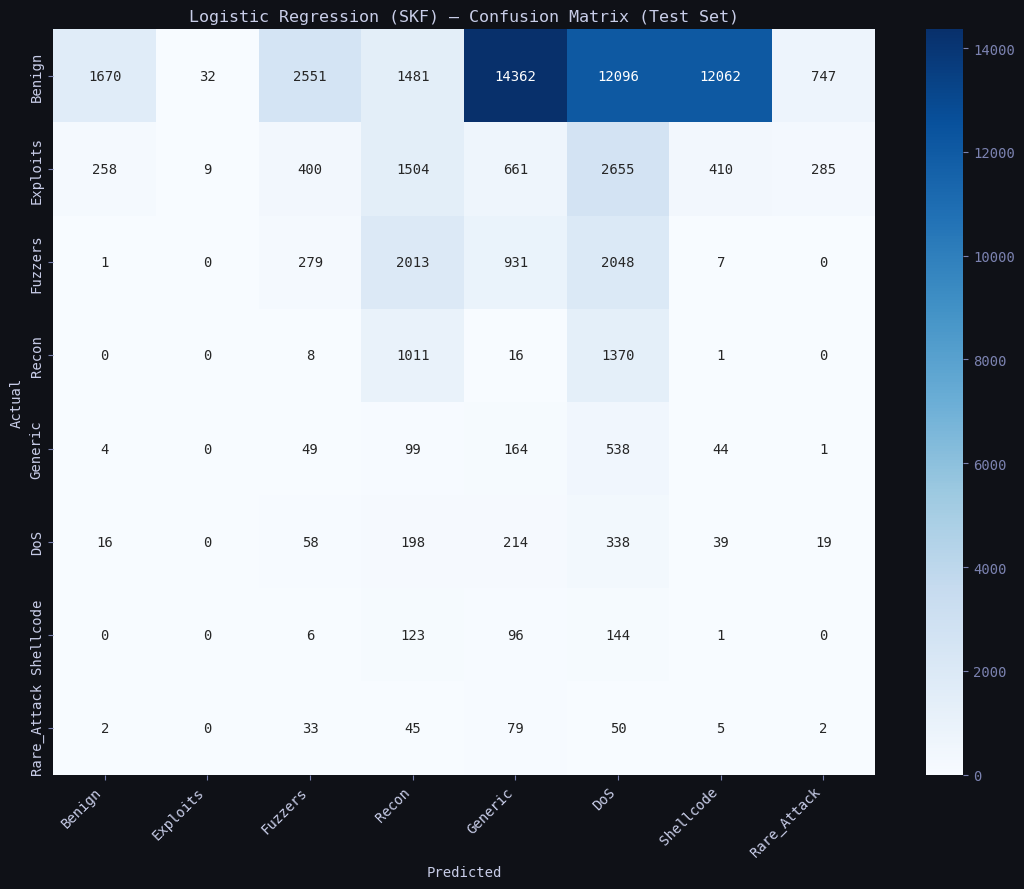

In [79]:
y_pred_lr_skf = lr_pipeline.predict(X_test)
plot_confusion_matrix(y_test, y_pred_lr_skf, LABEL_MAP, 'Logistic Regression (SKF) — Confusion Matrix (Test Set)')

#### Logistic Regression (SKF) — SHAP Feature Importance
`LinearExplainer` computes exact SHAP values for logistic regression using the pipeline's fitted scaler and model weights on the test set.

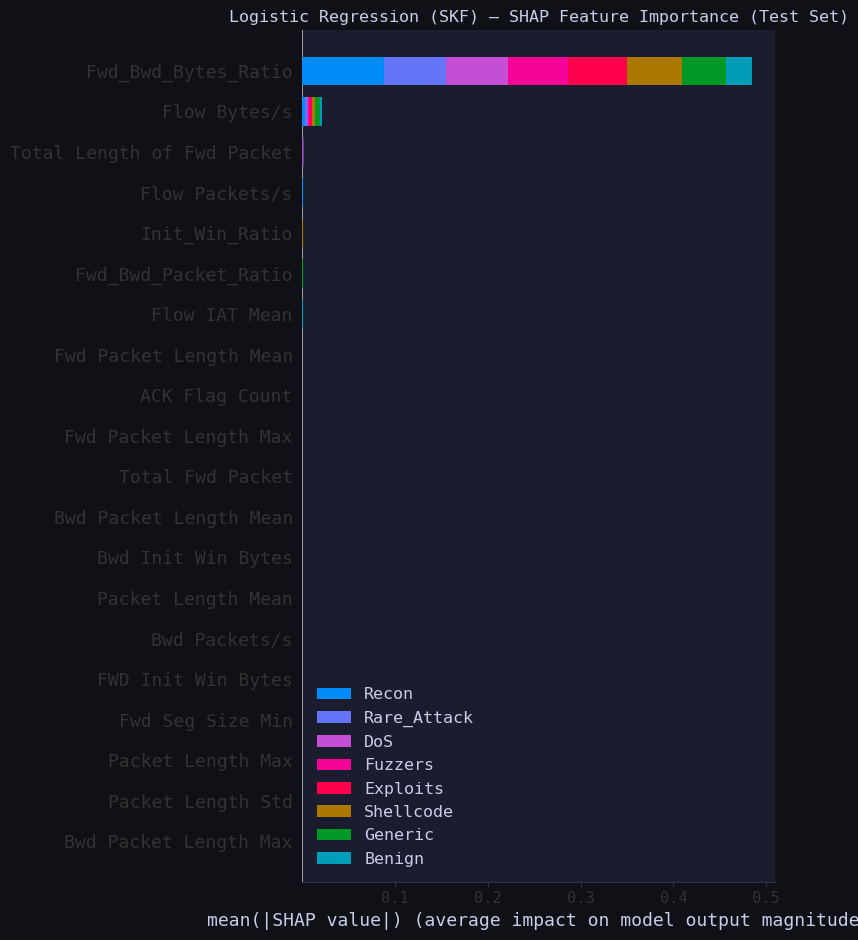

In [81]:
import shap

X_test_sample_lr = X_test.sample(n=min(500, len(X_test)), random_state=42)
# Apply the pipeline's fitted scaler — prevents re-fitting on test data
X_test_sample_lr_scaled = lr_pipeline.named_steps['scaler'].transform(X_test_sample_lr)

# LinearExplainer is exact for logistic regression; uses model coefficients directly
explainer_lr = shap.LinearExplainer(lr_pipeline.named_steps['model'], X_test_sample_lr_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_sample_lr_scaled)

plot_shap_bar(
    shap_values_lr, X_test_sample_lr_scaled,
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='Logistic Regression (SKF) — SHAP Feature Importance (Test Set)',
)

#### Logistic Regression — Precision-Recall Curves
Per-class precision-recall curves — more honest than ROC for the imbalanced class distribution.

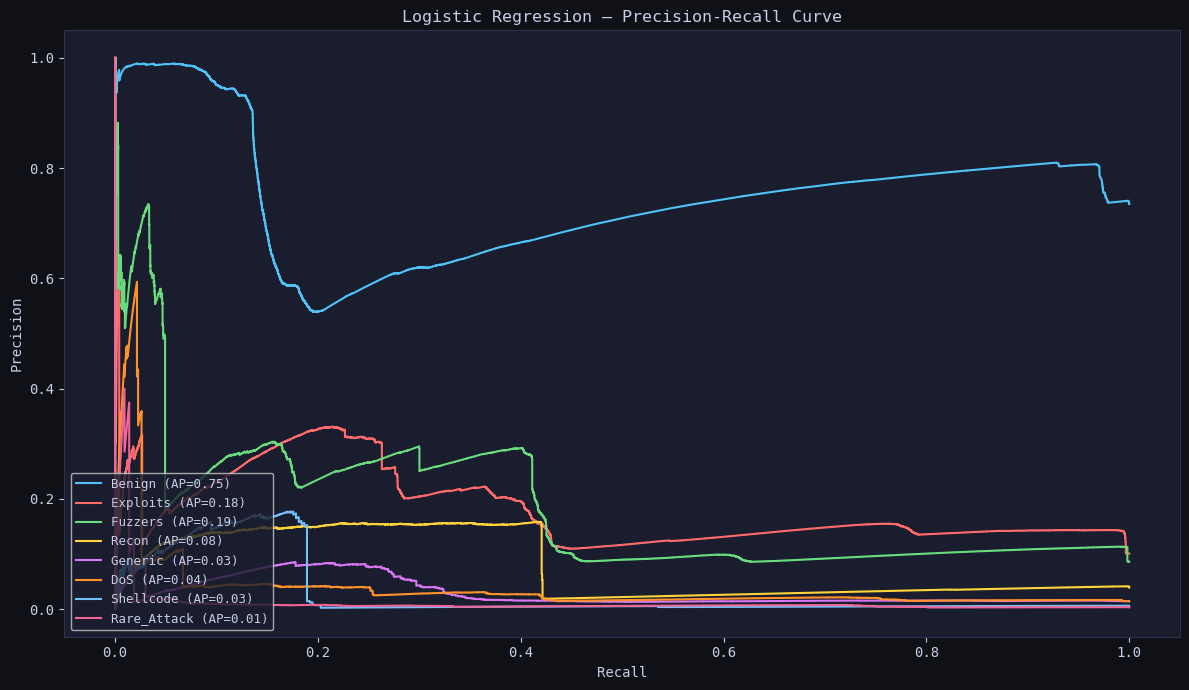

In [83]:
# label_binarize converts multi-class labels into one-vs-rest binary matrix
# PRC is more honest than ROC for imbalanced classes 

# get class labels from LABEL_MAP; order here does NOT control column order below
classes = list(LABEL_MAP.keys())
# one-hot encode true labels for One vs Rest; label_binarize sorts classes ascending internally, so column i = i-th smallest label value
y_test_bin = label_binarize(y_test, classes=classes) 
# predicted probabilities per class; column order follows lr_pipeline.classes_ (also sorted ascending by default). must match y_test_bin's column order for the indexing below to be valid
y_score_lr = lr_pipeline.predict_proba(X_test)

plot_precision_recall(y_test_bin, y_score_lr, LABEL_MAP, PALETTE, 'Logistic Regression — Precision-Recall Curve')

**VIF analysis revealed severe multicollinearity among packet length features, with values exceeding 100 for several variables. This rendered logistic regression ineffective as regularization had no meaningful impact on model coefficients, motivating the use of ensemble tree-based methods which are robust to multicollinearity by design.**


# Random Forest

#### Random Forest — Fit & Predict
Train a Random Forest with balanced class weights on the SMOTE-augmented training set.

In [87]:
# Random Forest — Hyperparameter Search + Final Fit

# CappedSMOTE runs inside each CV fold on the training split only — no leakage.
rf_cv_pipeline = Pipeline([
    SMOTE_STEP,
    ('scaler', RobustScaler()),
    ('model', RandomForestClassifier(
        min_samples_leaf=10,
        random_state=42, 
        class_weight = "balanced",
        n_jobs=1
    ))
])
#Hyperparam tuning 
param_dist_rf = {
    'model__n_estimators':     randint(100, 300),
    'model__max_depth':        [10, 20, 30, None],
    'model__max_features':     ['sqrt', 'log2', 0.3],
    'model__min_samples_leaf': [5, 10, 20],
}
#3 stratified k fold 
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#we do the randomoized search CV with the cv as the stratified k fold from above
gs_rf = RandomizedSearchCV(
    rf_cv_pipeline,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=skf,
    scoring={
        'accuracy':    'accuracy',
        'recall':      'recall_macro',
        'macro_f1':    'f1_macro',
        'weighted_f1': 'f1_weighted',
    },
    refit='macro_f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
    random_state=42
)

#fit the training data from gs_rf
gs_rf.fit(X_train, y_train)

print('=== Random Forest — RandomizedSearchCV ===')
print(f"Best params:      {gs_rf.best_params_}")
print(f"Best Macro F1:    {gs_rf.best_score_:.4f}")
res = gs_rf.cv_results_
b   = gs_rf.best_index_
print(f"Train Accuracy:   {res['mean_train_accuracy'][b]:.4f} ± {res['std_train_accuracy'][b]:.4f}")
print(f"Val  Accuracy:    {res['mean_test_accuracy'][b]:.4f} ± {res['std_test_accuracy'][b]:.4f}")
print(f"Train Macro F1:   {res['mean_train_macro_f1'][b]:.4f} ± {res['std_train_macro_f1'][b]:.4f}")
print(f"Val  Macro F1:    {res['mean_test_macro_f1'][b]:.4f} ± {res['std_test_macro_f1'][b]:.4f}")
print(f"Val  Weighted F1: {res['mean_test_weighted_f1'][b]:.4f} ± {res['std_test_weighted_f1'][b]:.4f}")

# Final fit using best params from search
best_rf_params = {k.replace('model__', ''): v for k, v in gs_rf.best_params_.items()}
#rf pipeline with the best paramaters
rf_pipeline = Pipeline([
    SMOTE_STEP,
    ('scaler', RobustScaler()),
    ('model', RandomForestClassifier(
        **best_rf_params,
        random_state=42,
        n_jobs=1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print('\n=== Random Forest — Train vs Test Score (overfitting check) ===')
print(f'  Training Score: {rf_pipeline.score(X_train, y_train):.4f}')
print(f'  Testing Score:  {rf_pipeline.score(X_test, y_test):.4f}')
print()
print('=== Random Forest — Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_rf,
    target_names=list(LABEL_MAP.values()),
    digits=4
))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
=== Random Forest — RandomizedSearchCV ===
Best params:      {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 157}
Best Macro F1:    0.5922
Train Accuracy:   0.9074 ± 0.0009
Val  Accuracy:    0.8856 ± 0.0000
Train Macro F1:   0.6922 ± 0.0030
Val  Macro F1:    0.5922 ± 0.0020
Val  Weighted F1: 0.8940 ± 0.0003

=== Random Forest — Train vs Test Score (overfitting check) ===
  Training Score: 0.9115
  Testing Score:  0.8950

=== Random Forest — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9992    0.9620    0.9802     45001
    Exploits     0.8610    0.6721    0.7549      6182
     Fuzzers     0.5759    0.8763    0.6950      5279
       Recon     0.6866    0.5773    0.6272      2406
     Generic     0.7500    0.7608    0.7554       899
         DoS     0.4102    0.3753    0.3919       882
   Shellcode     

#### Random Forest — Cross-Validation
5-fold stratified cross-validation for the Random Forest.

#### Random Forest (SKF) — Confusion Matrix
Test-set confusion matrix using the pipeline fitted above.

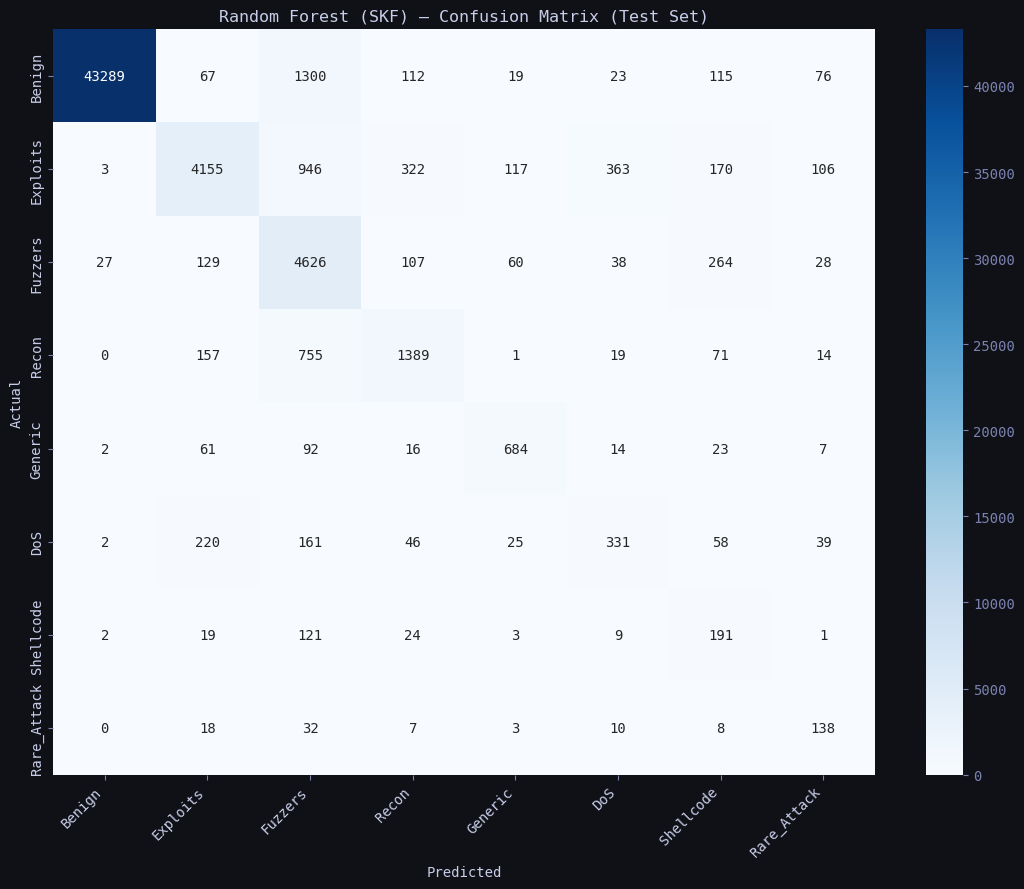

In [90]:
y_pred_rf_skf = rf_pipeline.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf_skf, LABEL_MAP, 'Random Forest (SKF) — Confusion Matrix (Test Set)')

#### Random Forest (SKF) — SHAP Feature Importance
`TreeExplainer` computes exact SHAP values for Random Forest using the pipeline's fitted scaler on the test set.

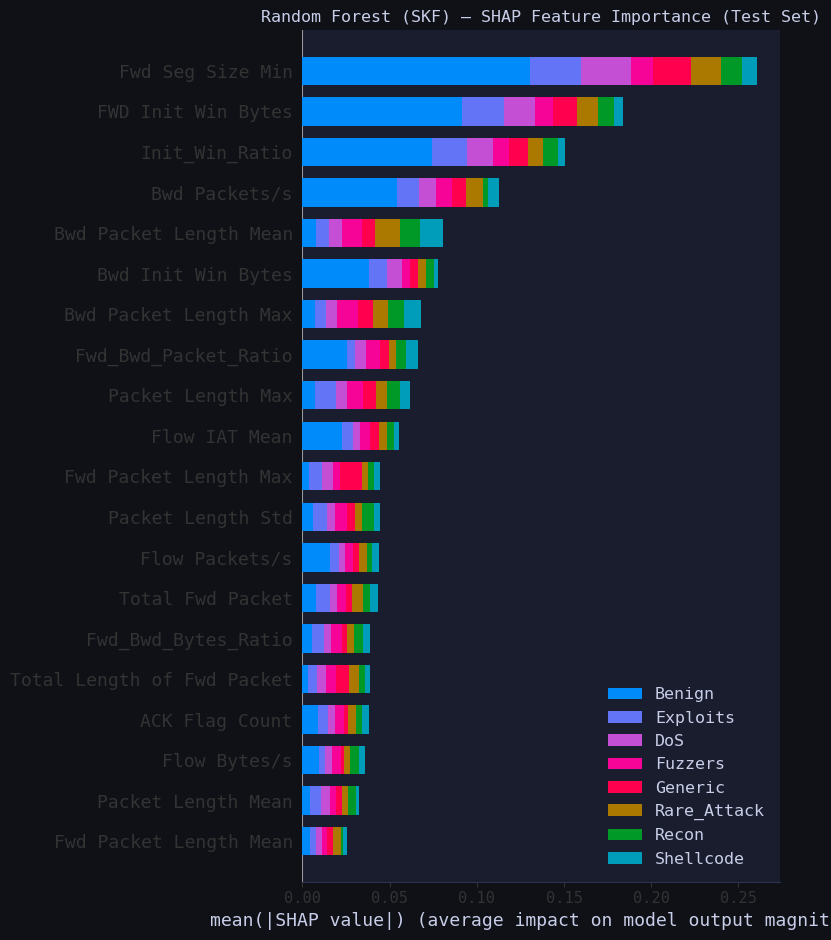

In [92]:
X_test_sample_rf = X_test.sample(n=min(500, len(X_test)), random_state=42)
# Apply the pipeline's fitted scaler — no refitting on test data
X_test_sample_rf_scaled = rf_pipeline.named_steps['scaler'].transform(X_test_sample_rf)

# TreeExplainer is exact for Random Forest; much faster than KernelExplainer
explainer_rf = shap.TreeExplainer(rf_pipeline.named_steps['model'])
shap_values_rf = explainer_rf.shap_values(X_test_sample_rf_scaled)


plot_shap_bar(
    shap_values_rf, X_test_sample_rf_scaled,
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='Random Forest (SKF) — SHAP Feature Importance (Test Set)',
)

#### Random Forest — Precision-Recall Curves
Per-class precision-recall curves for Random Forest.

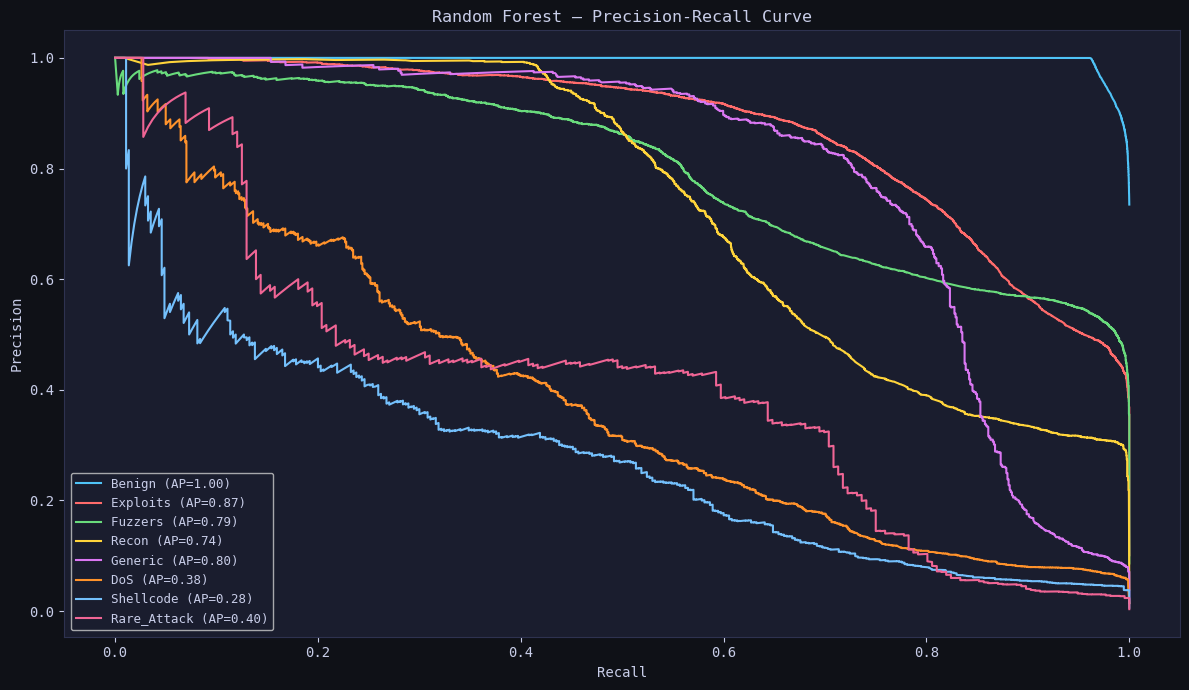

In [94]:
y_score_rf = rf_pipeline.predict_proba(X_test)
plot_precision_recall(y_test_bin, y_score_rf, LABEL_MAP, PALETTE, 'Random Forest — Precision-Recall Curve')

# XGBoost

#### XGBoost — Fit & Predict
Train XGBoost with histogram tree method and multi-class log-loss, then generate test-set predictions.

In [97]:
# XGBoost — Hyperparameter Search + Final Fit 

# CappedSMOTE runs inside each CV fold on the training split only — no leakage.
xgb_cv_pipeline = Pipeline([
    SMOTE_STEP,
    ('scaler', RobustScaler()),
    ('model', XGBClassifier(
        tree_method='hist',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=1
    ))
])

param_dist_xgb = {
    'model__n_estimators':  randint(50, 300),
    'model__max_depth':     randint(3, 10),
    'model__learning_rate': loguniform(1e-3, 0.3),
    'model__subsample':     uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 10),
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gs_xgb = RandomizedSearchCV(
    xgb_cv_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=skf,
    scoring={
        'accuracy':    'accuracy', 
        'recall':      'recall_macro',
        'macro_f1':    'f1_macro',
        'weighted_f1': 'f1_weighted',
    },
    refit='macro_f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
    random_state=42
)


gs_xgb.fit(X_train, y_train)

print('=== XGBoost — RandomizedSearchCV ===')
print(f"Best params:      {gs_xgb.best_params_}")
print(f"Best Macro F1:    {gs_xgb.best_score_:.4f}")
res = gs_xgb.cv_results_
b   = gs_xgb.best_index_
print(f"Train Accuracy:   {res['mean_train_accuracy'][b]:.4f} ± {res['std_train_accuracy'][b]:.4f}")
print(f"Val  Accuracy:    {res['mean_test_accuracy'][b]:.4f} ± {res['std_test_accuracy'][b]:.4f}")
print(f"Train Macro F1:   {res['mean_train_macro_f1'][b]:.4f} ± {res['std_train_macro_f1'][b]:.4f}")
print(f"Val  Macro F1:    {res['mean_test_macro_f1'][b]:.4f} ± {res['std_test_macro_f1'][b]:.4f}")
print(f"Val  Weighted F1: {res['mean_test_weighted_f1'][b]:.4f} ± {res['std_test_weighted_f1'][b]:.4f}")

# Final fit using best params from search 
best_xgb_params = {
    k.replace('model__', ''): v
    for k, v in gs_xgb.best_params_.items()
}

xgb_pipeline = Pipeline([SMOTE_STEP,
    ('scaler', RobustScaler()),
    ('model', XGBClassifier(
        **best_xgb_params,
        tree_method='hist',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

print('\n=== XGBoost — Train vs Test Score (overfitting check) ===')
print(f'  Training Score: {xgb_pipeline.score(X_train, y_train):.4f}')
print(f'  Testing Score:  {xgb_pipeline.score(X_test, y_test):.4f}')
print()
print('=== XGBoost — Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_xgb,
    target_names=list(LABEL_MAP.values()),
    digits=4
))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
=== XGBoost — RandomizedSearchCV ===
Best params:      {'model__colsample_bytree': 0.6390688456025535, 'model__learning_rate': 0.04953682563497157, 'model__max_depth': 9, 'model__min_child_weight': 7, 'model__n_estimators': 221, 'model__subsample': 0.798070764044508}
Best Macro F1:    0.5873
Train Accuracy:   0.8973 ± 0.0008
Val  Accuracy:    0.8878 ± 0.0008
Train Macro F1:   0.6408 ± 0.0038
Val  Macro F1:    0.5873 ± 0.0027
Val  Weighted F1: 0.8955 ± 0.0007

=== XGBoost — Train vs Test Score (overfitting check) ===
  Training Score: 0.8955
  Testing Score:  0.8905

=== XGBoost — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9997    0.9618    0.9804     45001
    Exploits     0.8548    0.6522    0.7399      6182
     Fuzzers     0.5713    0.8541    0.6847      5279
       Recon     0.6697    0.5806    0.6220      2406
     Generic     0.7207    0.7375    0.7290 

#### XGBoost (SKF) — Confusion Matrix
Test-set confusion matrix using the pipeline fitted above.

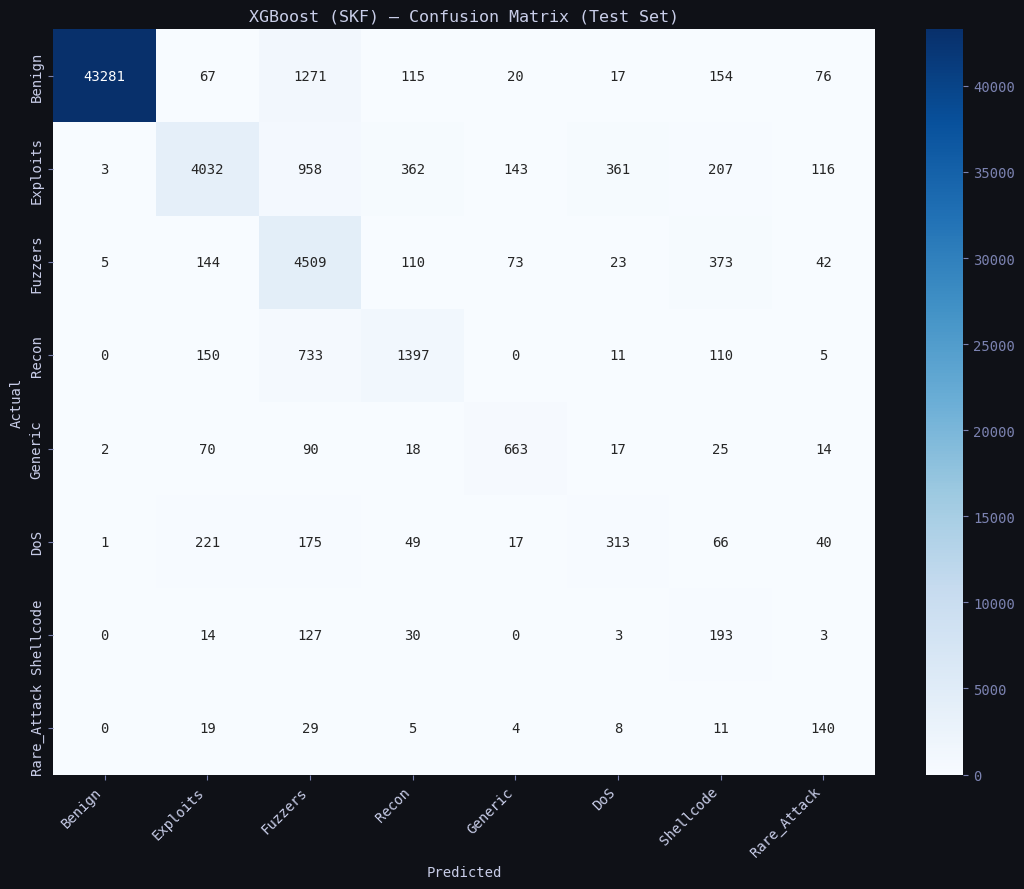

In [99]:
y_pred_xgb_skf = xgb_pipeline.predict(X_test)
plot_confusion_matrix(y_test, y_pred_xgb_skf, LABEL_MAP, 'XGBoost (SKF) — Confusion Matrix (Test Set)')

#### XGBoost (SKF) — SHAP Feature Importance
`TreeExplainer` computes exact SHAP values for XGBoost using the pipeline's fitted scaler on the test set.

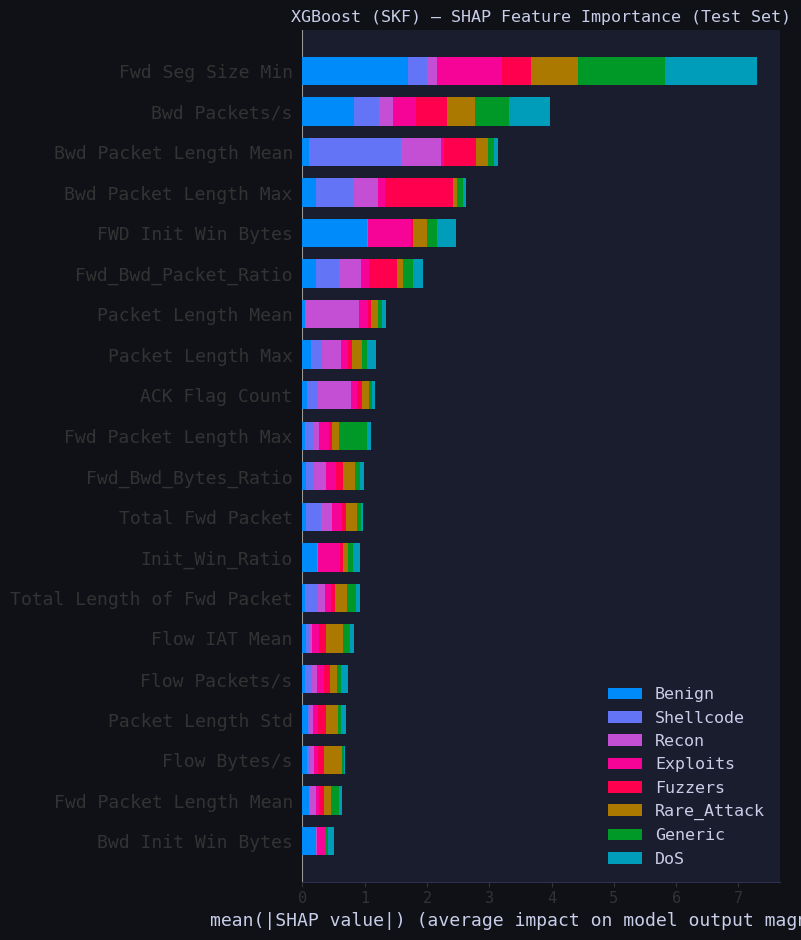

In [101]:
X_test_sample_xgb = X_test.sample(n=min(500, len(X_test)), random_state=42)
# Apply the pipeline's fitted scaler — no refitting on test data
X_test_sample_xgb_scaled = xgb_pipeline.named_steps['scaler'].transform(X_test_sample_xgb)

# XGBoost's native SHAP implementation via TreeExplainer — exact and fast
explainer_xgb = shap.TreeExplainer(xgb_pipeline.named_steps['model'])
shap_values_xgb = explainer_xgb.shap_values(X_test_sample_xgb_scaled)

plot_shap_bar(
    shap_values_xgb, X_test_sample_xgb_scaled,
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='XGBoost (SKF) — SHAP Feature Importance (Test Set)',
)

#### XGBoost — Precision-Recall Curves
Per-class precision-recall curves for XGBoost.

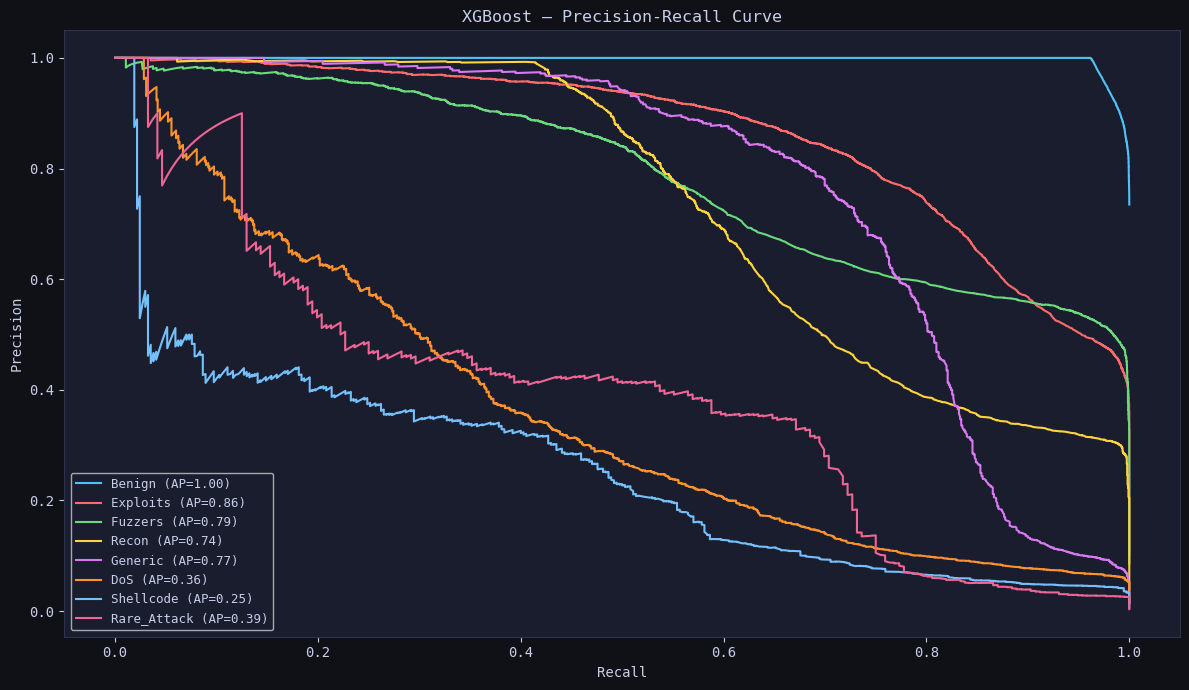

In [103]:
y_score_xgb = xgb_pipeline.predict_proba(X_test)
plot_precision_recall(y_test_bin, y_score_xgb, LABEL_MAP, PALETTE, 'XGBoost — Precision-Recall Curve')

# MLP

#### MLP — Model Definition
Define `TabularDataset` (wraps scaled arrays as PyTorch tensors) and `MLPClassifier` — stacked Linear → ReLU → Dropout blocks with a final classifier head.

In [106]:
# Wraps numpy arrays as a PyTorch Dataset so DataLoader can batch them
class TabularDataset(Dataset):
    def __init__(self, X, y):
        # Convert feature array to float32 tensor
        self.X = torch.tensor(X, dtype=torch.float32)
        # Convert labels to long tensor required by CrossEntropyLoss
        self.y = torch.tensor(np.array(y), dtype=torch.long)
#Returns the total number of samples so we know how many batches per epoch 
    def __len__(self):
        return len(self.X)
#Returns a single (features, label) pair at position. collects the results, and stacks them into batches automatically
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# num_layers blocks of Linear → ReLU → Dropout(0.3), then a classifier head
class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        layers = []
        in_dim = input_size
        for _ in range(num_layers):
            layers += [nn.Linear(in_dim, hidden_size), nn.ReLU(), nn.Dropout(0.3)]
            in_dim = hidden_size
        layers.append(nn.Linear(hidden_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


#### MLP — Build DataLoaders & Train
Create DataLoaders, instantiate the MLP, and run the training loop for 5 epochs.

In [108]:


# Three-way split: train / val / test — val is used for per-epoch checks, test is held out untouched until the end
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)  # 70% train, 30% held out for val+test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)  # split the remaining 30% -> 15% val, 15% test

# Balance and scale — no CV here so pre-fitting is correct
sm = CappedSMOTE(cap_ratio=0.10, random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

# Fit scaler on balanced training data only — val/test never influence scaling
scaler = RobustScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_val_scaled        = scaler.transform(X_val)   # transform only, never fit — val must stay unseen by the scaler's fitting process
X_test_scaled       = scaler.transform(X_test)

# Pick GPU if available, else fall back to CPU — determines where tensors/model will live
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# wrap balanced/scaled train arrays into a PyTorch Dataset
train_ds = TabularDataset(X_train_bal_scaled, y_train_bal)
# wrap scaled val arrays (unbalanced — correct, val should reflect real-world class distribution)
val_ds   = TabularDataset(X_val_scaled, y_val)
# wrap scaled test arrays (unbalanced — correct, test should reflect real-world class distribution)
test_ds  = TabularDataset(X_test_scaled, y_test)

# shuffle train each epoch to avoid batch-order bias
train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True,  num_workers=0)
# no need to shuffle val — order doesn't affect evaluation
val_loader   = DataLoader(val_ds,   batch_size=2048, shuffle=False, num_workers=0)
# no need to shuffle test — order doesn't affect evaluation
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False, num_workers=0)

mlp_model = MLPClassifier(
    input_size=X_train_bal_scaled.shape[1],  # number of input features, inferred from data shape
    hidden_size=128,                          # width of each hidden layer
    num_layers=2,                             # depth of the MLP
    num_classes=len(LABEL_MAP)                # output size = number of attack/benign classes
).to(device)  # move model weights to GPU/CPU

# standard multi-class loss; expects raw logits + integer class labels
criterion = nn.CrossEntropyLoss()
# Adam optimizer, common default learning rate
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)
# cut Learning Rate in half every 10 epochs to help convergence late in training
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 25

# track training metrics per epoch for later plotting
mlp_train_accs, mlp_train_losses = [], []
# track validation accuracy per epoch (now genuinely held-out, not test data)
mlp_val_accs = []

for epoch in range(EPOCHS):
# Training
    mlp_model.train()  # set model to train mode (enables dropout/batchnorm behavior if present)
    total_loss, correct, total = 0, 0, 0  # reset running counters each epoch
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move batch to GPU/CPU
        optimizer.zero_grad()  # clear gradients from previous batch — required every iteration in PyTorch
        logits = mlp_model(X_batch)  # forward pass, raw unnormalized scores per class
        loss   = criterion(logits, y_batch)  # compute cross-entropy loss vs true labels
        loss.backward()  # backprop — compute gradients
        optimizer.step()  # update model weights using gradients
        total_loss += loss.item()  # accumulate scalar loss for epoch average
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()  # count correct predictions in this batch
        total      += len(y_batch)  # count total samples seen this batch
    epoch_acc  = correct / total  # training accuracy for the epoch
    epoch_loss = total_loss / len(train_loader)  # average training loss for the epoch
    mlp_train_accs.append(epoch_acc)
    mlp_train_losses.append(epoch_loss)

# Validation — uses val_loader, kept separate from test_loader to avoid leakage via epoch-by-epoch monitoring
    mlp_model.eval()  # set model to eval mode (disables dropout etc.)
    val_correct, val_total = 0, 0
    with torch.no_grad():  # disable gradient tracking — faster, less memory, no backprop needed for eval
        for X_batch, y_batch in val_loader:  # <-- changed from test_loader
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits     = mlp_model(X_batch)  # forward pass only, no loss/backward needed
            val_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            val_total   += len(y_batch)
    val_acc = val_correct / val_total  # validation accuracy for the epoch
    mlp_val_accs.append(val_acc)

    scheduler.step()  # advance the LR scheduler by one epoch (decays LR every 10 epochs per step_size)
    print(f'Train Acc: {epoch_acc:.4f}  Val Acc: {val_acc:.4f}')

mlp_model.eval()  # ensure model left in eval mode after training loop finishes (e.g. before inference/saving)

# Final, one-time evaluation on the untouched test set — this is the only number that should end up in your report
test_correct, test_total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = mlp_model(X_batch)
        test_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        test_total   += len(y_batch)
test_acc = test_correct / test_total
print(f'Final Test Acc: {test_acc:.4f}')

Using device: cpu
Train Acc: 0.5696  Val Acc: 0.7236
Train Acc: 0.6363  Val Acc: 0.7695
Train Acc: 0.6660  Val Acc: 0.7539
Train Acc: 0.6775  Val Acc: 0.7767
Train Acc: 0.6873  Val Acc: 0.7834
Train Acc: 0.6931  Val Acc: 0.7966
Train Acc: 0.6969  Val Acc: 0.8004
Train Acc: 0.7000  Val Acc: 0.8013
Train Acc: 0.7021  Val Acc: 0.7989
Train Acc: 0.7043  Val Acc: 0.8019
Train Acc: 0.7058  Val Acc: 0.8029
Train Acc: 0.7076  Val Acc: 0.8039
Train Acc: 0.7077  Val Acc: 0.8061
Train Acc: 0.7093  Val Acc: 0.8129
Train Acc: 0.7097  Val Acc: 0.8111
Train Acc: 0.7106  Val Acc: 0.8111
Train Acc: 0.7125  Val Acc: 0.8126
Train Acc: 0.7126  Val Acc: 0.8120
Train Acc: 0.7136  Val Acc: 0.8152
Train Acc: 0.7148  Val Acc: 0.8134
Train Acc: 0.7149  Val Acc: 0.8144
Train Acc: 0.7160  Val Acc: 0.8155
Train Acc: 0.7166  Val Acc: 0.8156
Train Acc: 0.7162  Val Acc: 0.8156
Train Acc: 0.7169  Val Acc: 0.8156
Final Test Acc: 0.8182


#### MLP — Evaluate
Switch to eval mode and collect per-batch predictions and class probabilities on the test set.

In [110]:
mlp_model.eval()  # ensure model is in eval mode before running any inference below

# Test inference — generate final predictions and probabilities on the held-out test set
all_preds, all_probs = [], []  # collect predicted classes and predicted probabilities across all test batches
with torch.no_grad():  # no gradients needed for inference
    for X_batch, _ in test_loader:  # labels (_) not needed here, only predictions
        logits = mlp_model(X_batch.to(device))  # forward pass -> raw logits
        all_preds.append(logits.argmax(dim=1).cpu())  # hard class prediction per sample, moved back to CPU
        all_probs.append(torch.softmax(logits, dim=1).cpu())  # convert logits to probabilities per class, moved back to CPU
y_pred_mlp = torch.cat(all_preds).numpy()  # concatenate all batches into one array of predicted labels
y_score_mlp = torch.cat(all_probs).numpy()  # concatenate all batches into one array of predicted probabilities (for PR/ROC curves later)

# Train inference (overfitting check) — run the trained model on its own training data to compare train vs test performance
train_preds_all = []  # collect predicted classes on training data
with torch.no_grad():
    for X_batch, _ in DataLoader(train_ds, batch_size=2048, shuffle=False, num_workers=0):  # fresh unshuffled loader so predictions line up with y_train_bal order
        logits = mlp_model(X_batch.to(device))
        train_preds_all.append(logits.argmax(dim=1).cpu())
y_pred_mlp_train = torch.cat(train_preds_all).numpy()  # concatenate into one array of predicted labels on train data

# y_train_bal contains the balanced labels that train_ds was built from
train_acc = accuracy_score(y_train_bal, y_pred_mlp_train)  # accuracy on (balanced, oversampled) training data
test_acc = accuracy_score(y_test, y_pred_mlp)  # accuracy on real, untouched, imbalanced test data
gap = train_acc - test_acc  # large positive gap suggests the model memorized train data rather than generalizing

print('=== MLP — Train vs Test Score (overfitting check) ===')
print(f'  Training Accuracy: {train_acc:.4f}')
print(f'  Testing  Accuracy: {test_acc:.4f}')
print(f'  Gap (train-test):  {gap:.4f}  {"possible overfit" if gap > 0.05 else "looks healthy"}')  # arbitrary 0.05 threshold flags overfitting risk
print()

print('=== MLP — Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_mlp,               # true vs predicted labels, both on the real test distribution
    target_names=list(LABEL_MAP.values()),  # use human-readable class names instead of integer codes
    digits=4                          # show precision/recall/F1 to 4 decimal places
))

=== MLP — Train vs Test Score (overfitting check) ===
  Training Accuracy: 0.7247
  Testing  Accuracy: 0.8182
  Gap (train-test):  -0.0935  looks healthy

=== MLP — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9988    0.9371    0.9670     33750
    Exploits     0.9056    0.4284    0.5816      4636
     Fuzzers     0.5201    0.5066    0.5132      3960
       Recon     0.2233    0.7856    0.3478      1805
     Generic     0.4611    0.5007    0.4801       675
         DoS     0.2732    0.0755    0.1183       662
   Shellcode     0.2362    0.2166    0.2260       277
 Rare_Attack     0.1331    0.5714    0.2160       161

    accuracy                         0.8182     45926
   macro avg     0.4689    0.5027    0.4313     45926
weighted avg     0.8916    0.8182    0.8381     45926



#### MLP — Confusion Matrix
Plot the confusion matrix on the held-out test set.

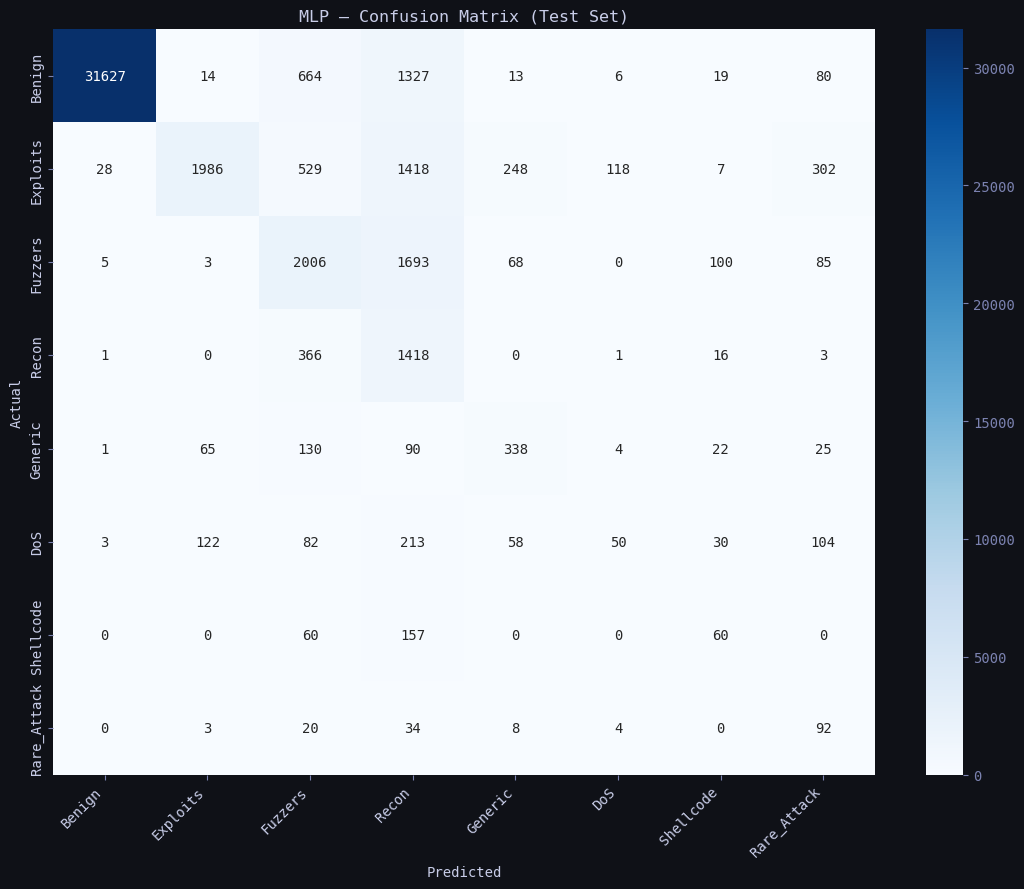

In [112]:
plot_confusion_matrix(y_test, y_pred_mlp, LABEL_MAP, 'MLP — Confusion Matrix (Test Set)')

#### MLP — Precision-Recall Curves
Per-class precision-recall curves for the MLP — more informative than ROC for imbalanced classes.

45926 45926


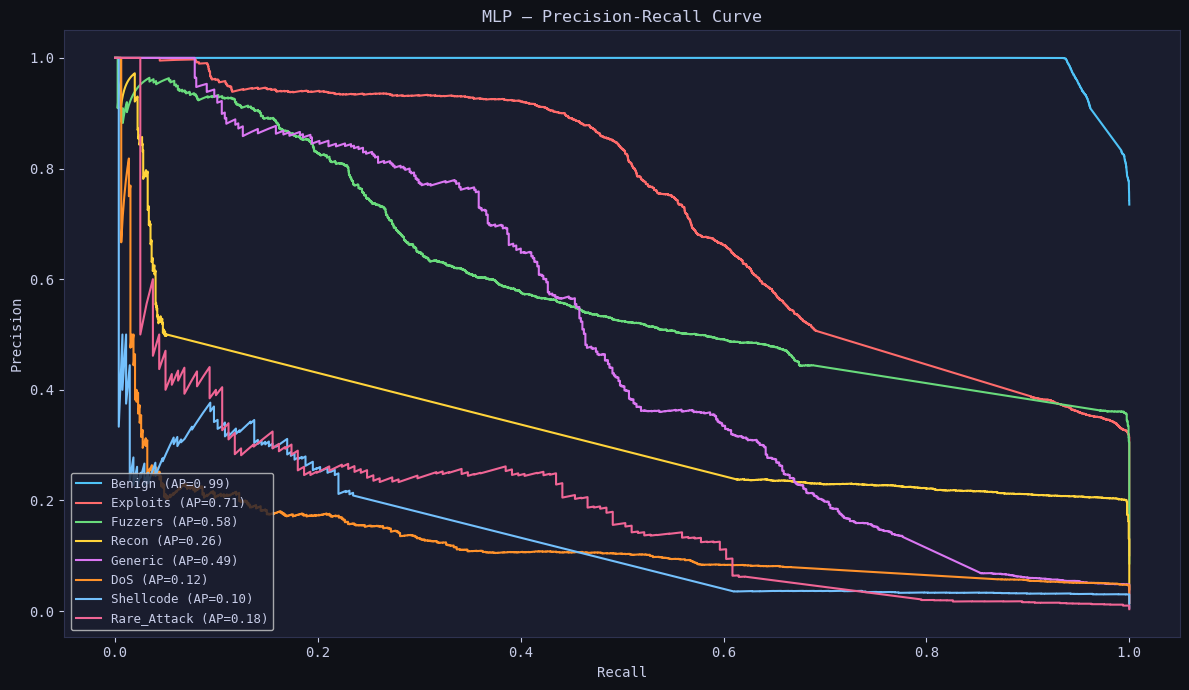

In [114]:
# Rebuild AFTER the val/test split — must match the current y_test, not the old one
classes = list(LABEL_MAP.keys())
y_test_bin = label_binarize(y_test, classes=classes)

# Sanity check — these must match before plotting
print(y_test_bin.shape[0], y_score_mlp.shape[0])  # should now be equal

plot_precision_recall(y_test_bin, y_score_mlp, LABEL_MAP, PALETTE, 'MLP — Precision-Recall Curve')

#### MLP — SHAP Feature Importance
`GradientExplainer` approximates SHAP values for the PyTorch MLP via integrated gradients on a 300-sample slice of the test set and aggregates across all 10 output classes. (`DeepExplainer` / DeepLIFT is the alternative — both are valid for PyTorch; `GradientExplainer` is more stable when the network contains dropout layers.)

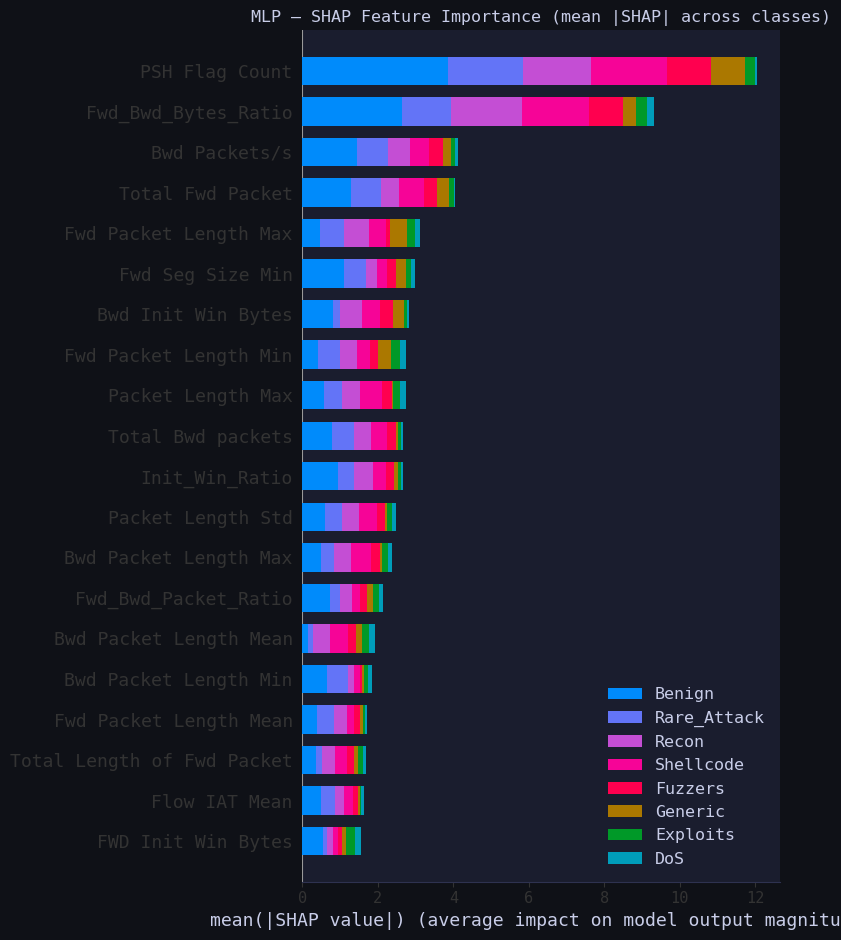

In [116]:
mlp_model.eval()
background_mlp = torch.FloatTensor(X_train_bal_scaled[:100])
# GradientExplainer (integrated gradients) — preferred over DeepExplainer when dropout is present
explainer_mlp_shap = shap.GradientExplainer(mlp_model, background_mlp)
sample_scaled_mlp = torch.FloatTensor(X_test_scaled[100:400])
shap_values_mlp_deep = explainer_mlp_shap.shap_values(sample_scaled_mlp)
# shap_values_mlp_deep is a list of 8 arrays each (300, 20) — pass directly to summary_plot
plot_shap_bar(
    shap_values_mlp_deep, X_test_scaled[100:400],
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='MLP — SHAP Feature Importance (mean |SHAP| across classes)',
)

In [117]:
# Logistic Regression: check expected columns, realign, regenerate predictions
lr_expected_cols = lr_pipeline.named_steps['scaler'].feature_names_in_
print(f"LR expects {len(lr_expected_cols)} columns")
X_test_lr_aligned = X_test[lr_expected_cols]
y_score_lr = lr_pipeline.predict_proba(X_test_lr_aligned)
print(f"New y_score_lr length: {y_score_lr.shape[0]}")  # should print 45926

# Random Forest: check expected columns, realign, regenerate predictions
rf_expected_cols = rf_pipeline.named_steps['scaler'].feature_names_in_
print(f"RF expects {len(rf_expected_cols)} columns")
X_test_rf_aligned = X_test[rf_expected_cols]
y_pred_rf = rf_pipeline.predict(X_test_rf_aligned)
print(f"New y_pred_rf length: {len(y_pred_rf)}")  # should print 45926

# XGBoost: check expected columns, realign, regenerate predictions
xgb_expected_cols = xgb_pipeline.named_steps['scaler'].feature_names_in_
print(f"XGB expects {len(xgb_expected_cols)} columns")
X_test_xgb_aligned = X_test[xgb_expected_cols]
y_pred_xgb = xgb_pipeline.predict(X_test_xgb_aligned)
print(f"New y_pred_xgb length: {len(y_pred_xgb)}")  # should print 45926 

LR expects 20 columns
New y_score_lr length: 45926
RF expects 20 columns
New y_pred_rf length: 45926
XGB expects 20 columns
New y_pred_xgb length: 45926


In [118]:
# check expected columns, realign, regenerate predictions
mlp_expected_cols = scaler.feature_names_in_  # the standalone RobustScaler used for MLP
print(f"MLP expects {len(mlp_expected_cols)} columns")
X_test_mlp_aligned = X_test[mlp_expected_cols]
X_test_mlp_scaled = scaler.transform(X_test_mlp_aligned)
mlp_model.eval()
with torch.no_grad():
    y_score_mlp = mlp_model(torch.tensor(X_test_mlp_scaled, dtype=torch.float32)).numpy()
print(f"New y_score_mlp length: {y_score_mlp.shape[0]}")  # should print 45926

MLP expects 28 columns
New y_score_mlp length: 45926


### Bridge — Collect Results & Build Named DataFrames
Aggregate each model's **test-set weighted F1** into `results`, then wrap the scaled numpy arrays back into pandas DataFrames so column names are preserved for all downstream cells.

LR expects 20 columns
New y_score_lr length: 45926
New y_pred_lr length: 45926
Model Comparison — Test-Set Weighted F1:
  Logistic Regression     weighted_f1=0.0667
  Random Forest           weighted_f1=0.9068
  XGBoost                 weighted_f1=0.9001
  MLP                     weighted_f1=0.8381

Length check (all should match):
  y_test:      45926
  y_test_bin:  45926
  y_score_lr:  45926
  y_score_rf:  45926
  y_score_xgb: 45926
  y_score_mlp: 45926


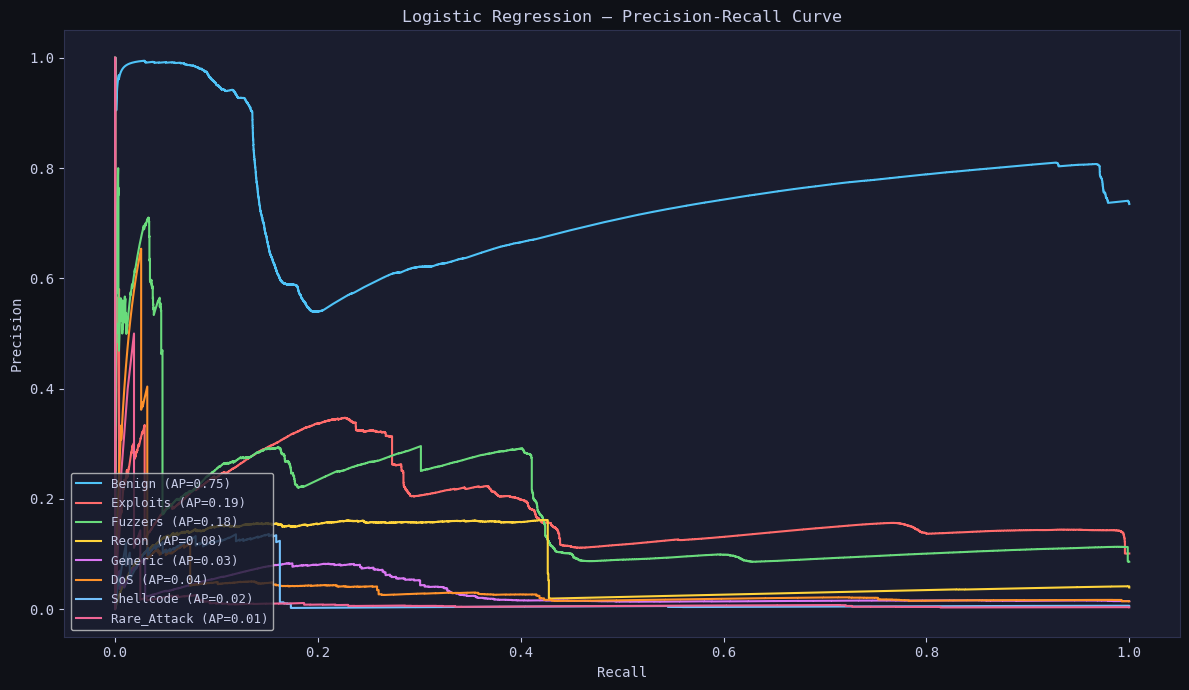

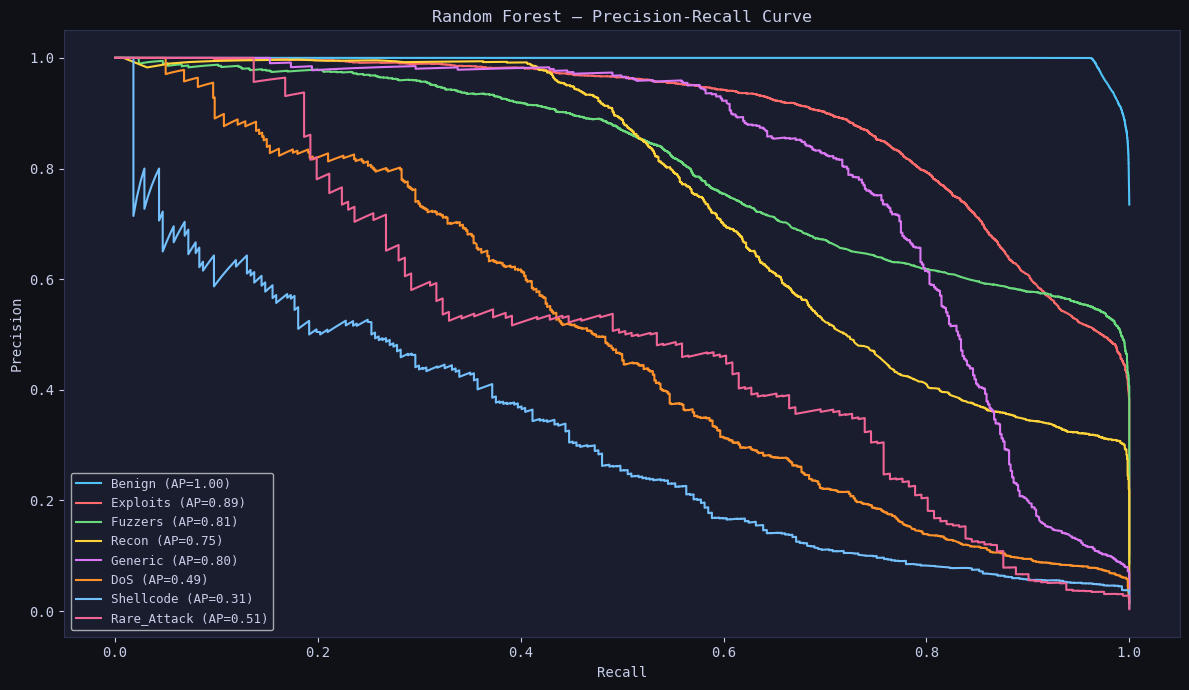

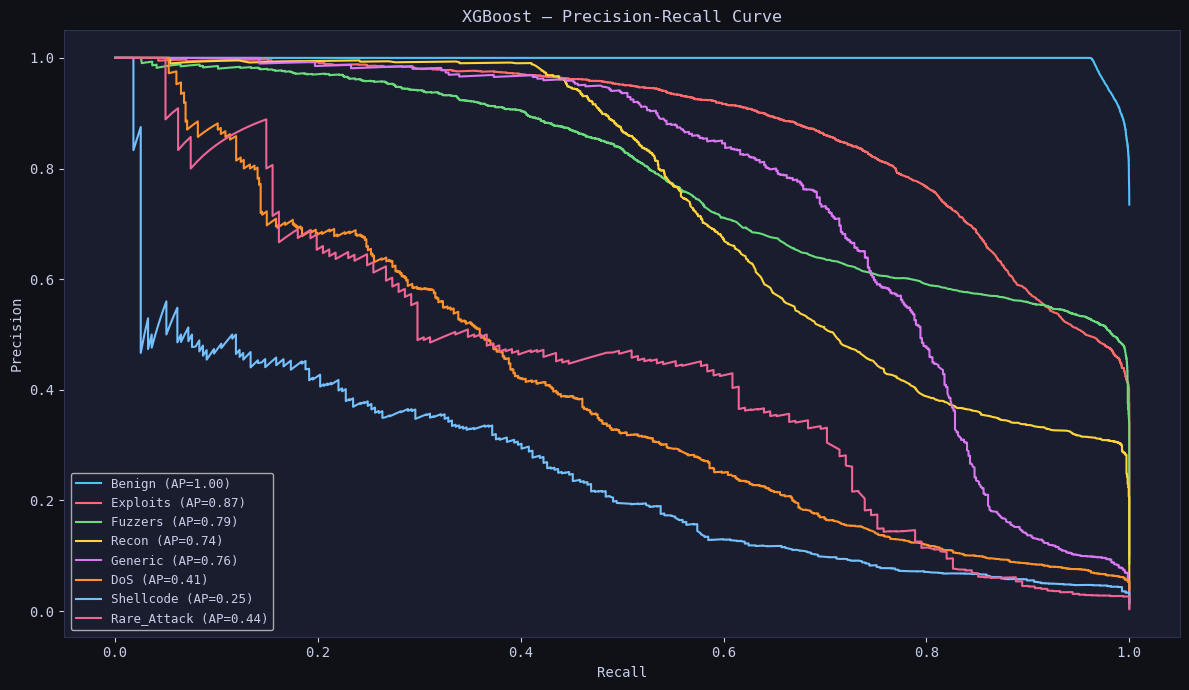

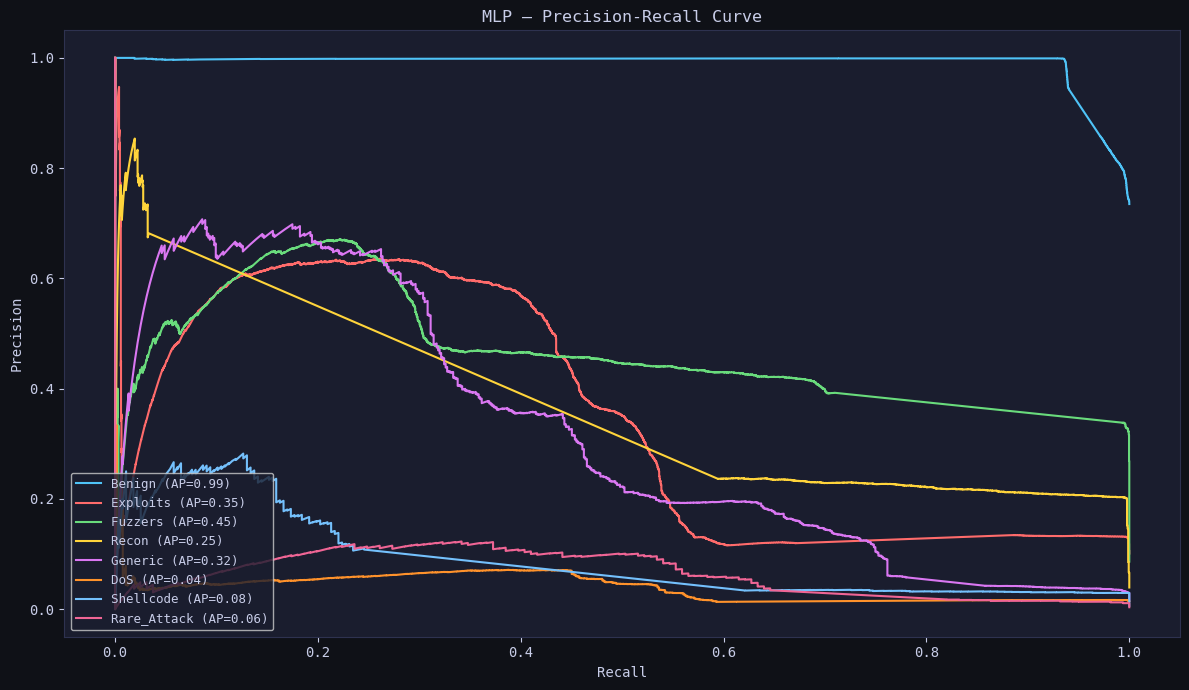


=== Random Forest — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9991    0.9625    0.9805     33750
    Exploits     0.8802    0.7069    0.7841      4636
     Fuzzers     0.5823    0.8811    0.7012      3960
       Recon     0.7003    0.5956    0.6437      1805
     Generic     0.7541    0.7541    0.7541       675
         DoS     0.5179    0.4366    0.4738       662
   Shellcode     0.2212    0.5126    0.3090       277
 Rare_Attack     0.3655    0.6584    0.4701       161

    accuracy                         0.9008     45926
   macro avg     0.6276    0.6884    0.6395     45926
weighted avg     0.9220    0.9008    0.9068     45926


=== XGBoost — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9996    0.9620    0.9805     33750
    Exploits     0.8664    0.6717    0.7567      4636
     Fuzzers     0.5734    0.8449    0.6832      3960
       Recon     0.671

In [120]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import label_binarize

# Regenerate LR predictions on the aligned test set (fixes stale y_pred_lr) 
lr_expected_cols = lr_pipeline.named_steps['scaler'].feature_names_in_
print(f"LR expects {len(lr_expected_cols)} columns")
X_test_lr_aligned = X_test[lr_expected_cols]
y_score_lr = lr_pipeline.predict_proba(X_test_lr_aligned)
y_pred_lr  = lr_pipeline.predict(X_test_lr_aligned)
print(f"New y_score_lr length: {y_score_lr.shape[0]}")  # should print 45926
print(f"New y_pred_lr length: {len(y_pred_lr)}")          # should print 45926

#1. Weighted F1 comparison across all four models 
results = [
    {"name": "Logistic Regression", "weighted_f1": f1_score(y_test, y_pred_lr,  average="weighted")},
    {"name": "Random Forest",       "weighted_f1": f1_score(y_test, y_pred_rf,  average="weighted")},
    {"name": "XGBoost",             "weighted_f1": f1_score(y_test, y_pred_xgb, average="weighted")},
    {"name": "MLP",                 "weighted_f1": f1_score(y_test, y_pred_mlp, average="weighted")},
]

print("Model Comparison — Test-Set Weighted F1:")
for r in results:
    print(f"  {r['name']:<22}  weighted_f1={r['weighted_f1']:.4f}")

# Regenerate probability scores for RF and XGBoost (needed for PR curves) ---
y_score_rf  = rf_pipeline.predict_proba(X_test_rf_aligned)
y_score_xgb = xgb_pipeline.predict_proba(X_test_xgb_aligned)

# Rebuild y_test_bin against the current y_test ---
classes = list(LABEL_MAP.keys())
y_test_bin = label_binarize(y_test, classes=classes)

# Sanity check — everything should match y_test's length before plotting
print("\nLength check (all should match):")
print(f"  y_test:      {len(y_test)}")
print(f"  y_test_bin:  {y_test_bin.shape[0]}")
print(f"  y_score_lr:  {y_score_lr.shape[0]}")
print(f"  y_score_rf:  {y_score_rf.shape[0]}")
print(f"  y_score_xgb: {y_score_xgb.shape[0]}")
print(f"  y_score_mlp: {y_score_mlp.shape[0]}")

#  Precision-Recall curves for all four models ---
plot_precision_recall(y_test_bin, y_score_lr,  LABEL_MAP, PALETTE, 'Logistic Regression — Precision-Recall Curve')
plot_precision_recall(y_test_bin, y_score_rf,  LABEL_MAP, PALETTE, 'Random Forest — Precision-Recall Curve')
plot_precision_recall(y_test_bin, y_score_xgb, LABEL_MAP, PALETTE, 'XGBoost — Precision-Recall Curve')
plot_precision_recall(y_test_bin, y_score_mlp, LABEL_MAP, PALETTE, 'MLP — Precision-Recall Curve')

#  Classification reports for RF and XGBoost (LR and MLP already covered elsewhere) ---
print("\n=== Random Forest — Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_rf, target_names=list(LABEL_MAP.values()), digits=4))

print("\n=== XGBoost — Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_xgb, target_names=list(LABEL_MAP.values()), digits=4))

### Threshold Sensitivity — Attack Probability
For each threshold `t` in `[0.50, 0.55, …, 0.95]`, a sample is flagged as an attack when `P(attack) = 1 − P(Benign) ≥ t`; otherwise it is classified as Benign. The table and plots show how macro F1, attack recall, and attack precision change as the confidence bar rises.


=== Logistic Regression ===
 Threshold  Accuracy  Macro F1  Weighted F1  Attack Prec  Attack Rec  Attack F1
    0.5000    0.0302    0.0449       0.0166       0.2652      1.0000     0.4192
    0.5500    0.0302    0.0449       0.0166       0.2652      1.0000     0.4192
    0.6000    0.0302    0.0449       0.0166       0.2652      1.0000     0.4192
    0.6500    0.0303    0.0449       0.0168       0.2652      1.0000     0.4193
    0.7000    0.0304    0.0449       0.0169       0.2652      0.9998     0.4192
    0.7500    0.0304    0.0449       0.0169       0.2652      0.9998     0.4192
    0.8000    0.0305    0.0450       0.0172       0.2653      0.9998     0.4193
    0.8500    0.0307    0.0450       0.0175       0.2653      0.9998     0.4193
    0.9000    0.7205    0.1121       0.6189       0.3598      0.0328     0.0601
    0.9500    0.7349    0.1136       0.6251       0.9058      0.0205     0.0402

=== Random Forest ===
 Threshold  Accuracy  Macro F1  Weighted F1  Attack Prec  Attack Rec

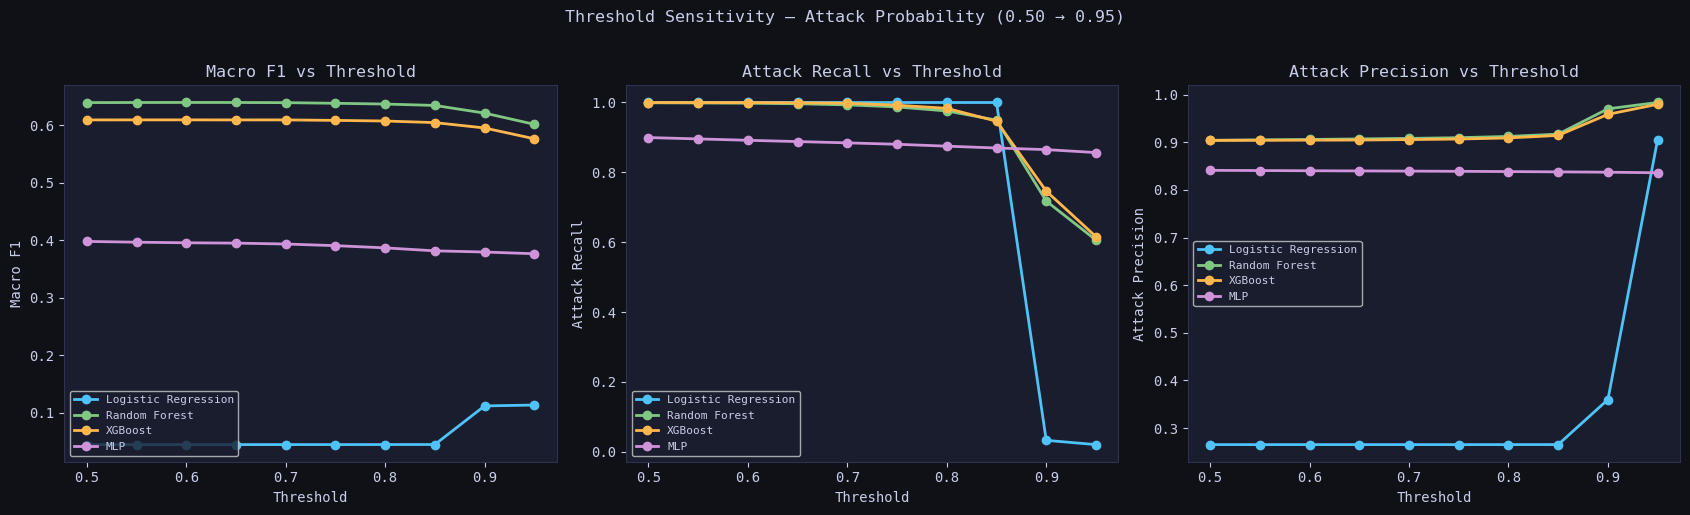

In [122]:

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

BENIGN_IDX = 0  # class 0 is Benign; all others are attacks

thresholds = np.round(np.arange(0.50, 0.96, 0.05), 2)

models = {
    'Logistic Regression': y_score_lr,
    'Random Forest': y_score_rf,
    'XGBoost': y_score_xgb,
    'MLP': y_score_mlp,
}

def threshold_predict(proba, t):
    # If attack probability (= 1 - P(Benign)) >= t, pick the top attack class; else Benign
    attack_prob = 1.0 - proba[:, BENIGN_IDX]
    return np.where(
        attack_prob >= t,
        proba[:, 1:].argmax(axis=1) + 1,  # +1 shifts attack-column indices back to class labels
        BENIGN_IDX,
    )

records = []
for name, proba in models.items():
    for t in thresholds:
        preds = threshold_predict(proba, t)
        y_bin_true = (y_test != BENIGN_IDX).astype(int)
        y_bin_pred = (preds  != BENIGN_IDX).astype(int)
        records.append({
            'Model':       name,
            'Threshold':   t,
            'Accuracy':    accuracy_score(y_test, preds),
            'Macro F1':    f1_score(y_test, preds, average='macro',    zero_division=0),
            'Weighted F1': f1_score(y_test, preds, average='weighted', zero_division=0),
            'Attack Prec': precision_score(y_bin_true, y_bin_pred, zero_division=0),
            'Attack Rec':  recall_score(y_bin_true, y_bin_pred, zero_division=0),
            'Attack F1':   f1_score(y_bin_true, y_bin_pred, zero_division=0),
        })

df_thresh = pd.DataFrame(records)

for name in models:
    sub = df_thresh[df_thresh['Model'] == name].drop(columns='Model')
    print(f'\n=== {name} ===')
    print(sub.to_string(index=False, float_format='{:.4f}'.format))

plot_threshold_sensitivity(df_thresh, models)

In [123]:
results = [
    {"name": "Logistic Regression", "weighted_f1": f1_score(y_test, y_pred_lr,   average="weighted")},
    {"name": "Random Forest",       "weighted_f1": f1_score(y_test, y_pred_rf,   average="weighted")},
    {"name": "XGBoost",             "weighted_f1": f1_score(y_test, y_pred_xgb,  average="weighted")},
    {"name": "MLP",                "weighted_f1": f1_score(y_test, y_pred_mlp,  average="weighted")},
] 
results

[{'name': 'Logistic Regression', 'weighted_f1': 0.06669638293613078},
 {'name': 'Random Forest', 'weighted_f1': 0.9068447876317772},
 {'name': 'XGBoost', 'weighted_f1': 0.9000508731529459},
 {'name': 'MLP', 'weighted_f1': 0.8381191860022307}]

In [124]:
import joblib
import json
from datetime import datetime

#1 Pick best sklearn model by weighted F1 
sklearn_results = [r for r in results if r["name"] != "MLP"]
best_result = max(sklearn_results, key=lambda r: r["weighted_f1"])
best_model_name = best_result["name"]
#looks up the different models 
model_lookup = {
    "Logistic Regression": lr_pipeline,
    "Random Forest":       rf_pipeline,
    "XGBoost":             xgb_pipeline,
} 
#chooses the best model
best_clf = model_lookup[best_model_name]

print(f"Best model: {best_model_name}  (weighted F1 = {best_result['weighted_f1']:.4f})")

#2. Save artifacts
import os 
#creates our artifcats in the path that we're in
os.makedirs("artifacts", exist_ok=True)
#saves the files to the path
joblib.dump(best_clf, "artifacts/model.pkl")
# save post selection feature order so inference can align incoming data
#feature_cols = X_test_final.columns.tolist() 
feature_cols = best_clf.named_steps['scaler'].feature_names_in_.tolist()
with open("artifacts/features.json", "w") as f:
    json.dump(feature_cols, f)
#maps the labels and references LABEL_MAP from above
label_map_str = {str(k): v for k, v in LABEL_MAP.items()}
with open("artifacts/label_map.json", "w") as f:
    json.dump(label_map_str, f, indent=2)
#model details
model_card = {
    "model_name":   best_model_name,
    "dataset":      "UNSW-NB15 2024",
    "weighted_f1":  best_result["weighted_f1"],
    "trained_at":   datetime.utcnow().isoformat(),
    "features":     len(feature_cols),
    "smote_applied": True,
    "scaler":       "RobustScaler (inside pipeline)",
    "classes":      label_map_str,
}
with open("artifacts/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)
#saves the artifacts
print("Saved: artifacts/model.pkl")
print("Saved: artifacts/features.json")
print("Saved: artifacts/label_map.json")
print("Saved: artifacts/model_card.json")

Best model: Random Forest  (weighted F1 = 0.9068)
Saved: artifacts/model.pkl
Saved: artifacts/features.json
Saved: artifacts/label_map.json
Saved: artifacts/model_card.json


In [129]:
# from elasticsearch import Elasticsearch
# from elasticsearch.helpers import bulk
# from datetime import datetime, timedelta
# #establish the Elasticsearch local host
# es = Elasticsearch("http://localhost:9200")

# # Build alert dataframe from test set results
# alert_df = pd.DataFrame({
#     'attack_score': 1.0 - y_score_rf[:, 0],
#     'pred_label':   [LABEL_MAP[i] for i in y_pred_rf],#assigns a prediction to each row
#     'true_label':   [LABEL_MAP[i] for i in y_test], #assigns if the label was correct
#     'alert_tier':   ['HIGH' if s >= 0.85 else 'MEDIUM' if s >= 0.50 else 'LOW' 
#                      for s in (1.0 - y_score_rf[:, 0])], #assigns the alert tier
#     'action':       ['ALERT - Escalate immediately' if s >= 0.85 
#                      else 'MONITOR - Flag for review' if s >= 0.50 
#                      else 'LOG - Routine logging' 
#                      for s in (1.0 - y_score_rf[:, 0])] #tells what actions we should take based on the alter tier
# })

# # Bulk ingest generates one Elasticsearch document per alert row
# def generate_docs(df): 
#     #  timestamps 1 second per alert into the past so the series ends at now
#     base_time = datetime.utcnow() - timedelta(hours=len(df)/3600) 
#     # _ discards the DataFrame index; i drives the per-alert timestamp offset
#     for i, (_, row) in enumerate(df.iterrows()):
#         yield { #yield (produces values one at a time on demand) makes generate_docs a generator function instead of a regular function.
#             "_index": "ids-alerts",# name of the Elasticsearch index, equivalent to a table in SQL
#             "_source": {
#                 # one second per alert, producing a synthetic time series
#                 "@timestamp": (base_time + timedelta(seconds=i)).isoformat(),# required by Kibana for time-based queries and timeline plots
#                 "attack_score": float(row["attack_score"]),# cast to Python native float numpy floats break JSON serialization
#                 "alert_tier":   row["alert_tier"],# HIGH / MEDIUM / LOW tier assigned by the alert engine
#                 "pred_label":   row["pred_label"],# attack class predicted by the model
#                 "true_label":   row["true_label"],# ground truth label from the dataset
#                 "action":       row["action"],# recommended action for this alert
#             }
#         }
# #tells us if the alerts went through and which ones did not and then prints them out
# #success, failed = bulk(es, generate_docs(alert_df))
# #print(f"Ingested {success} alerts | Failed: {failed}")

Ingested 45926 alerts | Failed: []


http://localhost:5601

docker run -d --name elasticsearch \
  -p 9200:9200 \
  -e "discovery.type=single-node" \
  -e "xpack.security.enabled=false" \
  docker.elastic.co/elasticsearch/elasticsearch:8.13.0

docker run -d --name kibana \
  -p 5601:5601 \
  -e "ELASTICSEARCH_HOSTS=http://elasticsearch:9200" \
  --link elasticsearch \
  docker.elastic.co/kibana/kibana:8.13.0

docker start elasticsearch

docker start kibana 

http://localhost:5601

In [137]:
# es.options(ignore_status=[404]).indices.delete(index="ids-alerts")
# print("Old index deleted (or didn't exist)")

# mapping = {
#     "mappings": {
#         "properties": {
#             "@timestamp":    {"type": "date"},
#             "attack_score":  {"type": "float"},
#             "alert_tier":    {"type": "keyword"},
#             "pred_label":    {"type": "keyword"},
#             "true_label":    {"type": "keyword"},
#             "action":        {"type": "keyword"},
#         }
#     }
# }
# es.indices.create(index="ids-alerts", body=mapping)
# print("Index recreated")

Old index deleted (or didn't exist)
Index recreated


In [139]:
#print(f"Ingested {success} alerts | Failed: {failed}")

Ingested 45926 alerts | Failed: []


In [141]:
#print(es.info())

{'name': 'f6f665b3ee78', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'Xwjhy9uwSACFXckqU9OekA', 'version': {'number': '8.13.0', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '09df99393193b2c53d92899662a8b8b3c55b45cd', 'build_date': '2024-03-22T03:35:46.757803203Z', 'build_snapshot': False, 'lucene_version': '9.10.0', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'}


In [143]:
from elasticsearch import Elasticsearch
from elasticsearch.helpers import bulk
from datetime import datetime, timedelta

es = Elasticsearch("http://localhost:9200")

# Step 1: reset index
es.options(ignore_status=[404]).indices.delete(index="ids-alerts")
mapping = {
    "mappings": {
        "properties": {
            "@timestamp":    {"type": "date"},
            "attack_score":  {"type": "float"},
            "alert_tier":    {"type": "keyword"},
            "pred_label":    {"type": "keyword"},
            "true_label":    {"type": "keyword"},
            "action":        {"type": "keyword"},
        }
    }
}
es.indices.create(index="ids-alerts", body=mapping)

# Step 2: build + ingest alerts (same cell, so no out-of-order risk)
alert_df = pd.DataFrame({
    'attack_score': 1.0 - y_score_rf[:, 0],
    'pred_label':   [LABEL_MAP[i] for i in y_pred_rf],
    'true_label':   [LABEL_MAP[i] for i in y_test],
    'alert_tier':   ['HIGH' if s >= 0.85 else 'MEDIUM' if s >= 0.50 else 'LOW'
                     for s in (1.0 - y_score_rf[:, 0])],
    'action':       ['ALERT - Escalate immediately' if s >= 0.85
                     else 'MONITOR - Flag for review' if s >= 0.50
                     else 'LOG - Routine logging'
                     for s in (1.0 - y_score_rf[:, 0])]
})

def generate_docs(df):
    base_time = datetime.utcnow() - timedelta(hours=len(df)/3600)
    for i, (_, row) in enumerate(df.iterrows()):
        yield {
            "_index": "ids-alerts",
            "_source": {
                "@timestamp": (base_time + timedelta(seconds=i)).isoformat(),
                "attack_score": float(row["attack_score"]),
                "alert_tier":   row["alert_tier"],
                "pred_label":   row["pred_label"],
                "true_label":   row["true_label"],
                "action":       row["action"],
            }
        }

success, failed = bulk(es, generate_docs(alert_df))
print(f"Ingested {success} alerts | Failed: {failed}")

es.indices.refresh(index="ids-alerts")
print(es.count(index="ids-alerts"))

Ingested 45926 alerts | Failed: []
{'count': 45926, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}}


# IDS Project — Full Build Roadmap
> **Core thesis:** A behavioral anomaly detector that analyzes statistical patterns across network flows to identify attack behavior — not individual packets, not signatures. Catches novel variants of known attack classes by learning what attacks *look like* over time.

---

## Foundation

| # | Phase | Time | Details |
|---|-------|------|---------|
| 1 | **Save model artifacts** | 30 min | `joblib.dump` best model + scaler, save feature col order as JSON, write model card. ⚠️ Do this first — everything else depends on it |
| 2 | **Reduce model runtime** | 3–5 hrs | Profile all 4 models; tune RF `max_depth` / `n_jobs`; sweep XGBoost `n_estimators`; benchmark MLP batch size. Pick best accuracy/speed tradeoff before freezing the model |

---

## The Bridge — Raw Traffic → Behavioral Features

| # | Phase | Time | Details |
|---|-------|------|---------|
| 3 | **Install + verify CICFlowMeter** | 1–2 hrs | Install Java, download CICFlowMeter JAR, run against a sample PCAP, confirm CSV output column names match training data exactly. ⚠️ CICFlowMeter collapses raw packets into the flow-level behavioral statistics your model was trained on — get this working in isolation first |
| 4 | **CICFlowMeter output cleaning layer** | 1–2 hrs | Strip column name spaces, fix casing, replace `Infinity`/`NaN` with 0, assert all 20 features present, align to saved feature col JSON. Without this, predictions will be silently wrong |
| 5 | **Validate feature distributions** | 1–2 hrs | Run CICFlowMeter on a known PCAP, compare output feature distributions against training data. ⚠️ This catches the core risk: CICFlowMeter computing behavioral features slightly differently on live traffic vs training data |

---

## Upload Mode — Forensic / Offline Behavioral Analysis

| # | Phase | Time | Details |
|---|-------|------|---------|
| 6 | **pyshark PCAP handler** | 1–2 hrs | pyshark validates + saves uploaded PCAP to temp path → CICFlowMeter extracts flow behavioral stats → cleaning layer → scaler → model classifies each flow. pyshark's only job is file handling |
| 7 | **End-to-end upload pipeline test** | 1–2 hrs | Upload a real PCAP → full pipeline → predictions. Use Wireshark sample PCAPs with known traffic types to verify behavioral patterns are classified correctly |

---

## Live Mode — Real-Time Behavioral Monitoring

| # | Phase | Time | Details |
|---|-------|------|---------|
| 8 | **pyshark live capture + rolling window** | 2–3 hrs | `pyshark.LiveCapture` buffers packets for N seconds → dumps to temp PCAP → same pipeline as upload mode. Model detects behavioral anomalies across completed flows every ~30s. This latency is normal — behavioral detection operates on flow patterns, not individual packets |
| 9 | **Live pipeline test** | 1 hr | Capture your own network traffic, confirm behavioral anomalies are flagged correctly, tune the rolling window interval. ★ This is the interview demo moment — live traffic classified in near-real time |

---

## Application Layer

| # | Phase | Time | Details |
|---|-------|------|---------|
| 10 | **FastAPI inference API** | 2–3 hrs | `POST /predict` for PCAP upload, `GET /live` to start/stop live behavioral monitoring, returns per-flow attack classifications + alert tiers as JSON |
| 11 | **Streamlit dashboard** | 2–3 hrs | PCAP upload + live capture toggle, flow classification table, alert tier badges, attack class distribution chart — pure Python |
| 12 | **Elasticsearch ingestion** | 2–3 hrs | Index schema + bulk ingest behavioral alerts. Elasticsearch enables tracking attack patterns over time — core to the behavioral detection thesis |
| 13 | **Kibana dashboards** | 2–3 hrs | Alert tier pie, attack class bar, behavioral score over time line, HIGH tier data table |

---

## Deployment + Portfolio

| # | Phase | Time | Details |
|---|-------|------|---------|
| 14 | **Docker Compose** | 3–5 hrs | 5 services: FastAPI, Streamlit, Elasticsearch, Kibana, Nginx reverse proxy. ★ Biggest single resume upgrade — turns a notebook into a deployable behavioral IDS |
| 15 | **README + write-up** | 2–3 hrs | Architecture diagram, setup instructions, design decisions, limitations section. Explain why flow-based behavioral detection complements signature-based tools like Snort/Suricata |

---

## Summary

| | |
|---|---|
| **Total estimate** | 4–5 focused weekends |
| **What the model does** | Classifies network flows as Benign or one of 9 attack types based on behavioral statistics |
| **Detection latency** | ~30–40 seconds — normal for behavioral flow analysis, not a flaw |
| **Critical path** | Phases 3–5 — validate CICFlowMeter feature output before building anything around it |
| **Upload before live** | Prove behavioral classification works on known PCAPs before trusting it on live traffic |
| **Start today** | Phase 1 — save model artifacts (30 min, unblocks everything) |